# Exploratory Data Analysis for Digital Marketing Revenue

This notebook explores the digital marketing dataset before regression modeling. The analysis focuses on understanding the `revenue` target, identifying the variables most likely to explain revenue variation, and translating analytical patterns into business insight.

The goal is intentionally exploratory: no model training, train/test split, or preprocessing pipeline is created here. Findings from this notebook should guide feature selection, transformations, and validation choices in the modeling notebook.


## 1. Project Overview

This project predicts marketing-driven `revenue` from campaign, platform, audience, timing, and performance metrics. In a regression setting, the EDA should answer three practical questions:

- How is revenue distributed, and does it contain many zero-revenue observations?
- Which marketing levers are most associated with revenue outcomes?
- Which data characteristics should shape downstream modeling decisions?

Because this is a digital marketing dataset, the analysis emphasizes campaign performance signals such as spend, impressions, clicks, conversions, platform, funnel stage, objective, and temporal seasonality.


## 2. Environment Setup

The notebook uses the standard scientific Python stack for tabular EDA: pandas and numpy for data manipulation, and matplotlib and seaborn for visualization.


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11


## 3. Load Dataset

The dataset is loaded from the repository's `data` folder. The path resolution below works whether the notebook is executed from the repository root or from inside the `notebooks` directory.


In [3]:
TARGET = "revenue"

candidate_paths = [
    Path("data/digital_marketing_dataset_30k.csv"),
    Path("../data/digital_marketing_dataset_30k.csv"),
]

csv_path = next((path for path in candidate_paths if path.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find data/digital_marketing_dataset_30k.csv from the current working directory.")

df = pd.read_csv(csv_path)

if TARGET not in df.columns:
    raise KeyError(f"Expected target column `{TARGET}` was not found. Available columns: {list(df.columns)}")

print(f"Loaded dataset from: {csv_path.resolve()}")
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
df.head()


Loaded dataset from: C:\Users\ggran\Desktop\F5\ai-project-regression-marketing\data\digital_marketing_dataset_30k.csv
Dataset shape: 30,000 rows x 35 columns


,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),is_weekend,is_weekend (text),country,market_tier,account,account_type,platform,placement,funnel_stage,objective,theme,campaign_id,campaign_name,ad_group_id,ad_group_name,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
0,08/04/2023,2023,4,Apr,14,Sat,7,Spring,0,No,1,Yes,Iraq,Tier 1,Travel_SkyTrip,Brand,TikTok,In-Feed,Awareness,Reach,Product Launch,C30853,Travel_SkyTrip_Product Launch_Awareness_TikTok...,AG412799,Product Launch_In-Feed_6,AD8747890,In-Feed_V1,871.17,172632,77865,2.22,1440,0,0.00,54610
1,28/04/2025,2025,4,Apr,18,Mon,12,Spring,0,No,0,No,Morocco,Tier 1,FMCG_Foodies,Brand,Meta,Feed,Awareness,Video Views,Seasonal,C49194,FMCG_Foodies_Seasonal_Awareness_Meta_Apr_2025,AG863446,Seasonal_Feed_42,AD2884130,Feed_V9,362.55,30111,15083,2.00,283,0,0.00,8086
2,18/12/2024,2024,12,Dec,51,Wed,10,Winter,0,No,0,No,United Arab Emirates,Tier 1,Ecom_FashionCo,Brand,Google Display,Display,Conversion,Sales,UGC,C54438,Ecom_FashionCo_UGC_Conversion_Google Display_D...,AG769411,UGC_Display_2,AD5656772,Display_V7,362.09,111125,56453,1.97,1238,7,671.74,0
3,26/04/2024,2024,4,Apr,17,Fri,20,Spring,0,No,0,No,KSA,Tier 1,Ecom_ElectroHub,Brand,Snapchat,Stories,Consideration,Traffic,Educational,C60684,Ecom_ElectroHub_Educational_Consideration_Snap...,AG131656,Educational_Stories_49,AD3443678,Stories_V2,54.45,10844,4736,2.29,83,0,0.00,0
4,19/04/2024,2024,4,Apr,16,Fri,22,Spring,0,No,0,No,Bahrain,Tier 3,FMCG_Foodies,Brand,Meta,Reels,Awareness,Reach,Retargeting,C57210,FMCG_Foodies_Retargeting_Awareness_Meta_Apr_2024,AG633873,Retargeting_Reels_37,AD8461978,Reels_V8,56.18,6423,3010,2.13,59,0,0.00,1160


**Interpretation.** The dataset is now available as `df`, with `revenue` kept as the regression target. The first rows provide a quick sense of campaign granularity and the mix of temporal, categorical, and numeric fields available for EDA.


## 4. Dataset Overview

This section gives a compact overview of column types, missingness, duplicate records, and basic descriptive statistics. It is intentionally brief so this notebook stays focused on exploratory patterns rather than repeating the dataset assessment notebook.


In [4]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique(dropna=True),
}).sort_values(["missing_pct", "unique_values"], ascending=[False, False])

display(overview)
print(f"Duplicate rows: {df.duplicated().sum():,}")
display(df.describe(include="number").T)


,dtype,non_null,missing,missing_pct,unique_values
ad_id,str,30000,0,0.00,29956
ad_group_id,str,30000,0,0.00,29496
campaign_id,str,30000,0,0.00,25548
impressions,int64,30000,0,0.00,25004
spend,float64,30000,0,0.00,24027
reach,int64,30000,0,0.00,21739
campaign_name,str,30000,0,0.00,19192
revenue,float64,30000,0,0.00,8744
video_views,int64,30000,0,0.00,8607
clicks,int64,30000,0,0.00,4279


Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
year,"30,000.00","2,024.00",0.82,"2,023.00","2,023.00","2,024.00","2,025.00","2,025.00"
month,"30,000.00",6.53,3.45,1.00,4.00,7.00,10.00,12.00
week,"30,000.00",26.46,15.09,1.00,13.00,27.00,40.00,52.00
post_hour,"30,000.00",11.50,6.92,0.00,5.00,11.00,18.00,23.00
is_holiday,"30,000.00",0.02,0.12,0.00,0.00,0.00,0.00,1.00
is_weekend,"30,000.00",0.28,0.45,0.00,0.00,0.00,1.00,1.00
spend,"30,000.00",421.21,463.30,18.84,86.15,229.91,609.31,"3,759.94"
impressions,"30,000.00","56,725.45","80,228.02",693.00,"9,432.75","25,438.00","69,614.50","1,015,972.00"
reach,"30,000.00","28,648.65","41,973.09",277.00,"4,652.75","12,516.00","34,562.25","682,100.00"
frequency,"30,000.00",2.07,0.42,1.11,1.75,2.06,2.37,3.20


**Interpretation.** Use this overview to confirm whether missingness or duplicated records need to be handled before modeling. For regression, the numeric summaries also flag skewed metrics and high-range variables that may benefit from transformations later.


## 5. Target Variable Analysis

Revenue is the prediction target, so its distribution determines how the modeling problem should be framed. Digital marketing revenue often has many zero values from awareness or traffic activity and a long right tail from high-performing conversion campaigns.


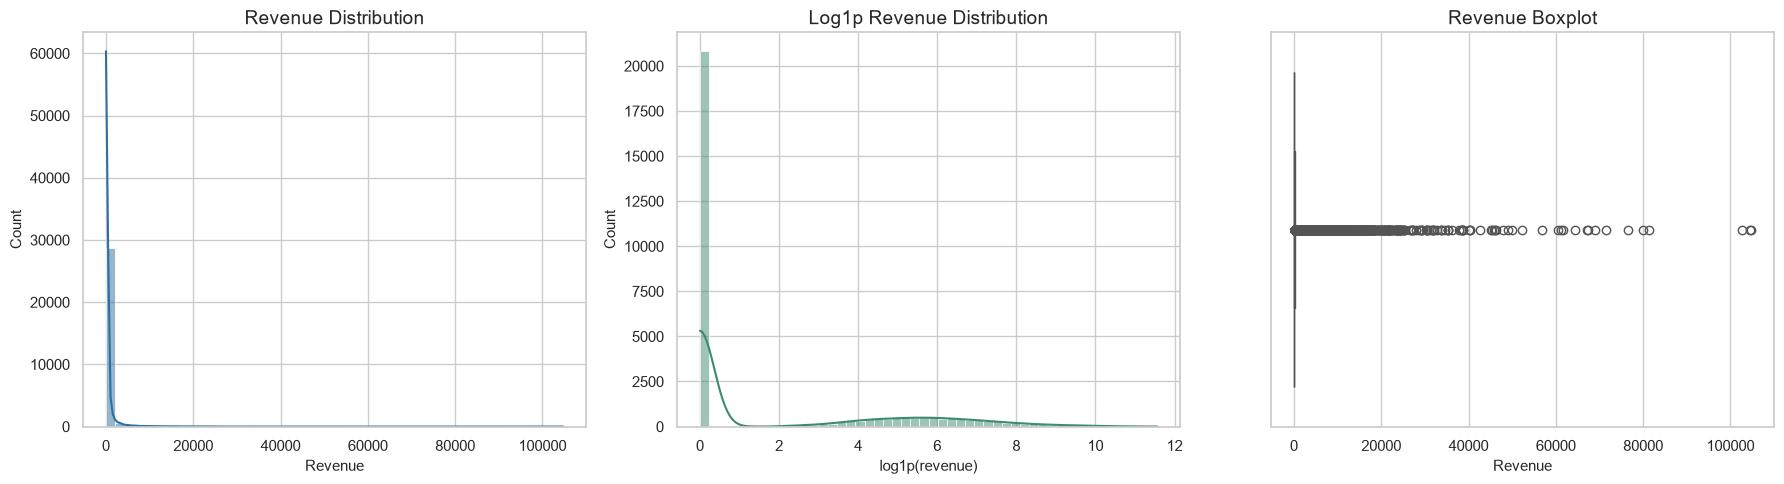

,revenue
count,"30,000.00"
mean,475.71
std,"2,814.17"
min,0.00
1%,0.00
5%,0.00
25%,0.00
50%,0.00
75%,72.35
95%,"1,745.70"


**Revenue interpretation.** Zero-revenue rows represent 69.4% of the dataset, while positive-revenue rows represent 30.6%. The log-scale view helps reveal structure hidden by high-revenue outliers.

In [5]:
revenue = df[TARGET].copy()
positive_revenue = revenue[revenue > 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(revenue, bins=50, kde=True, ax=axes[0], color="#2f6f9f")
axes[0].set_title("Revenue Distribution")
axes[0].set_xlabel("Revenue")

sns.histplot(np.log1p(revenue), bins=50, kde=True, ax=axes[1], color="#3d8b6f")
axes[1].set_title("Log1p Revenue Distribution")
axes[1].set_xlabel("log1p(revenue)")

sns.boxplot(x=revenue, ax=axes[2], color="#d28b46")
axes[2].set_title("Revenue Boxplot")
axes[2].set_xlabel("Revenue")

plt.tight_layout()
plt.show()

target_summary = revenue.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("revenue")
display(target_summary)

zero_share = (revenue == 0).mean() * 100
positive_share = (revenue > 0).mean() * 100
display(Markdown(
    f"**Revenue interpretation.** Zero-revenue rows represent {zero_share:.1f}% of the dataset, "
    f"while positive-revenue rows represent {positive_share:.1f}%. "
    "The log-scale view helps reveal structure hidden by high-revenue outliers."
))


**Interpretation.** If revenue is heavily zero-inflated or right-skewed, downstream modeling may need careful target transformation, robust metrics, or segment-aware validation. These decisions belong in the modeling notebook, but the evidence starts here.


## 6. Numerical Variables Analysis

Numerical campaign metrics describe scale, engagement, and performance intensity. This section reviews their distributions and creates common marketing KPI fields when they are absent from the raw dataset.


,count,mean,std,min,25%,50%,75%,max
spend,"30,000.00",421.21,463.30,18.84,86.15,229.91,609.31,"3,759.94"
impressions,"30,000.00","56,725.45","80,228.02",693.00,"9,432.75","25,438.00","69,614.50","1,015,972.00"
reach,"30,000.00","28,648.65","41,973.09",277.00,"4,652.75","12,516.00","34,562.25","682,100.00"
frequency,"30,000.00",2.07,0.42,1.11,1.75,2.06,2.37,3.20
clicks,"30,000.00",853.90,"1,485.99",3.00,109.00,311.50,961.00,"30,884.00"
conversions,"30,000.00",10.76,54.30,0.00,0.00,1.00,3.00,"2,701.00"
video_views,"30,000.00","5,176.54","13,486.54",0.00,0.00,0.00,"3,245.25","218,753.00"
cpm,"30,000.00",11.67,9.28,2.50,5.04,8.18,15.69,45.00
ctr,"30,000.00",0.02,0.02,0.00,0.01,0.01,0.01,0.14
cpc,"30,000.00",1.28,1.72,0.07,0.37,0.61,1.10,16.70


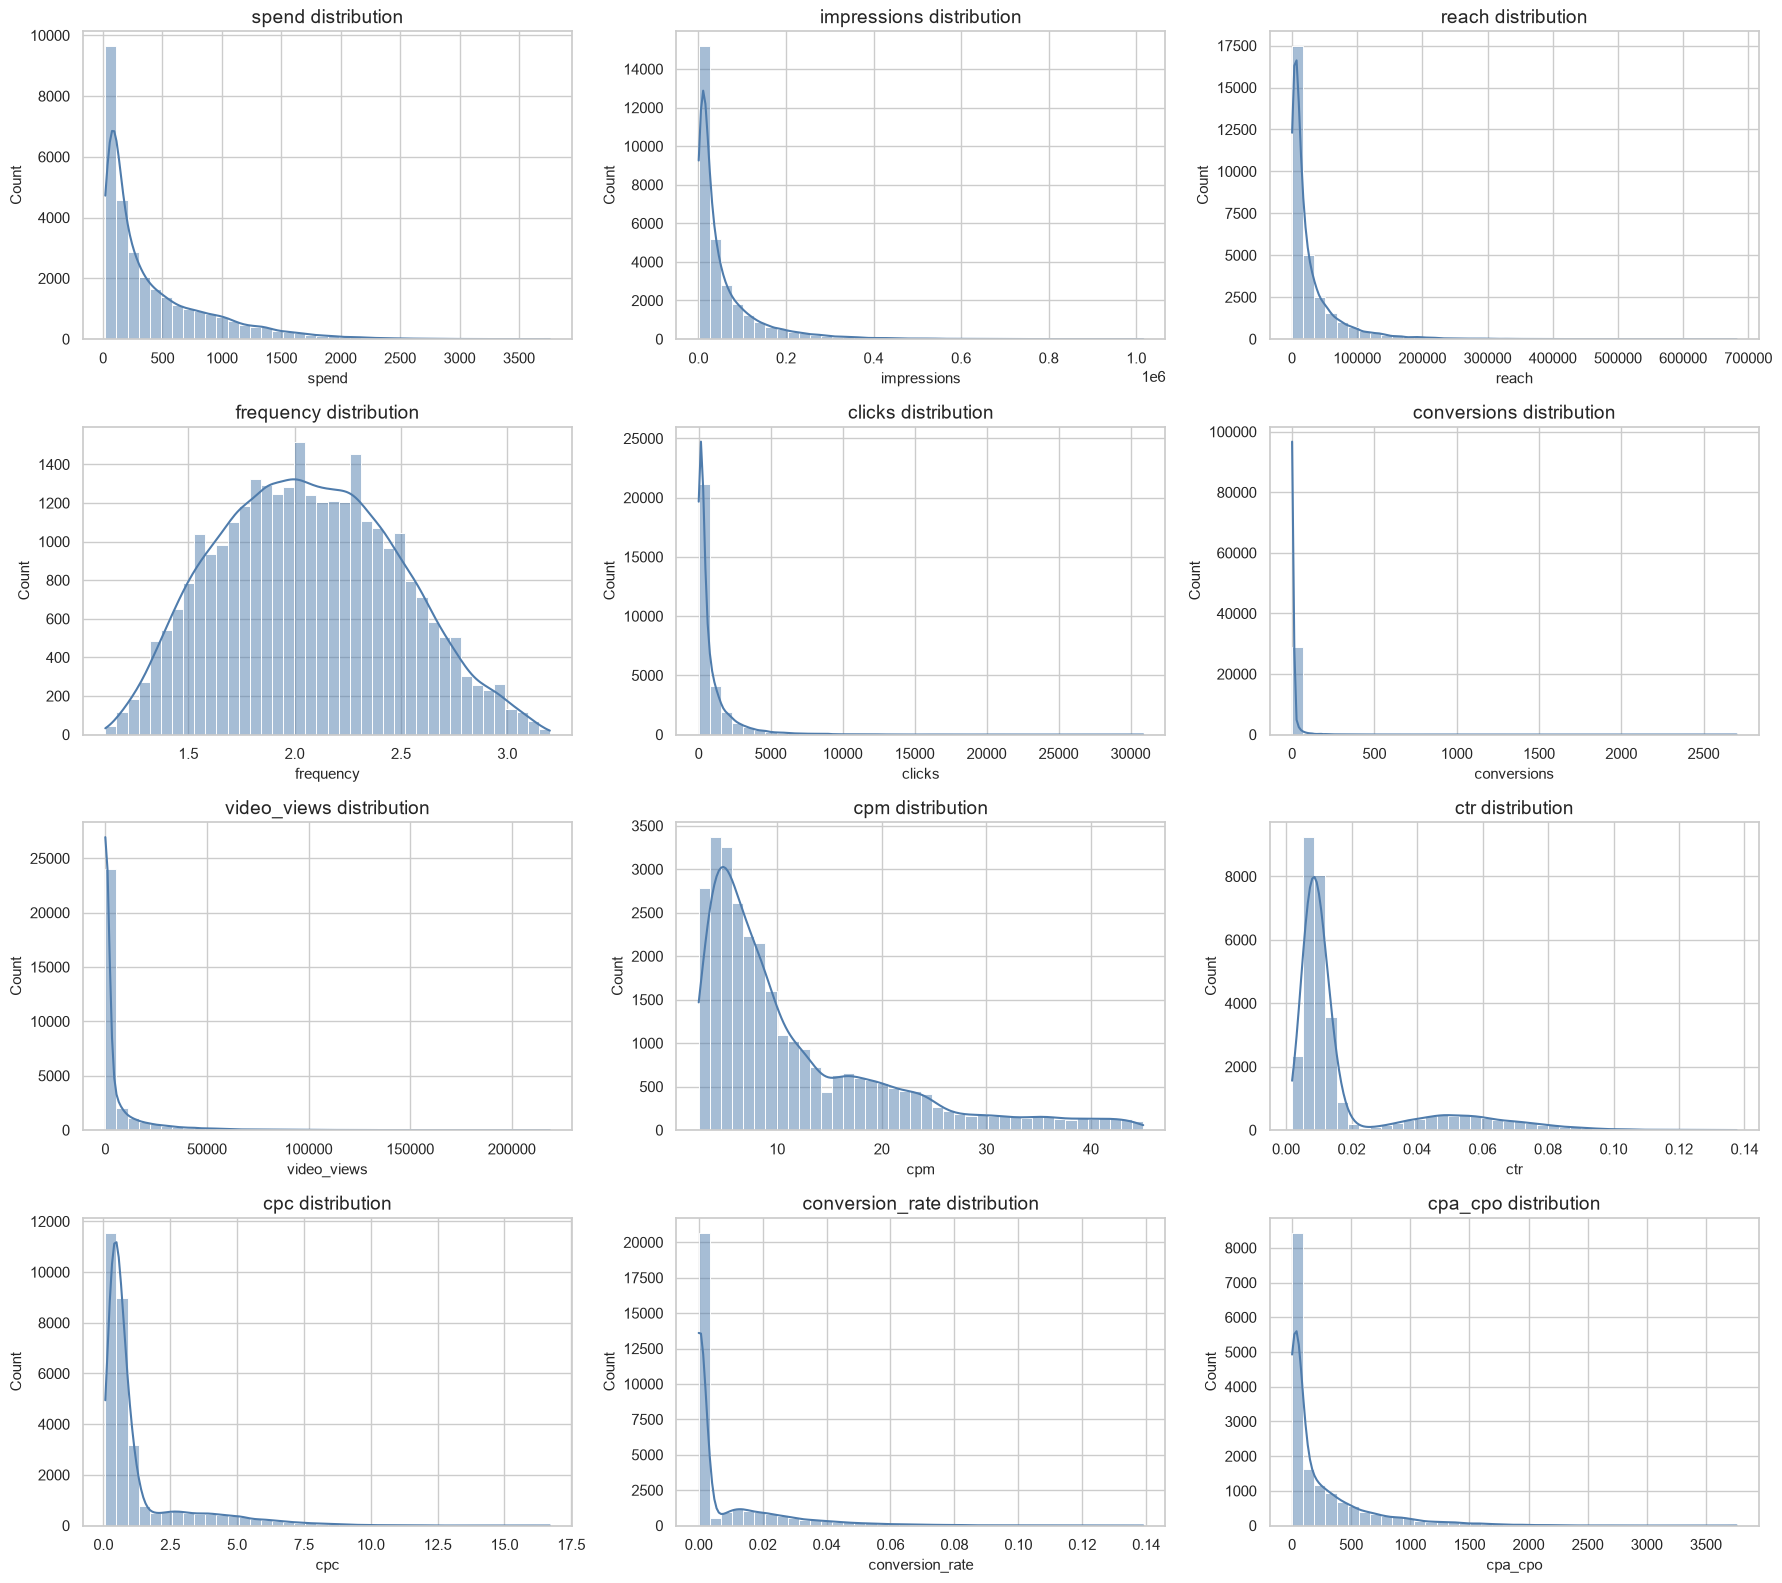

In [14]:
df_eda = df.copy()

if "date" in df_eda.columns:
    df_eda["date"] = pd.to_datetime(df_eda["date"], errors="coerce", dayfirst=True)

if "cpm" not in df_eda.columns and {"spend", "impressions"}.issubset(df_eda.columns):
    df_eda["cpm"] = np.where(df_eda["impressions"] > 0, df_eda["spend"] / df_eda["impressions"] * 1000, np.nan)
if "ctr" not in df_eda.columns and {"clicks", "impressions"}.issubset(df_eda.columns):
    df_eda["ctr"] = np.where(df_eda["impressions"] > 0, df_eda["clicks"] / df_eda["impressions"], np.nan)
if "cpc" not in df_eda.columns and {"spend", "clicks"}.issubset(df_eda.columns):
    df_eda["cpc"] = np.where(df_eda["clicks"] > 0, df_eda["spend"] / df_eda["clicks"], np.nan)
if "conversion_rate" not in df_eda.columns and {"conversions", "clicks"}.issubset(df_eda.columns):
    df_eda["conversion_rate"] = np.where(df_eda["clicks"] > 0, df_eda["conversions"] / df_eda["clicks"], np.nan)
if "cpa_cpo" not in df_eda.columns and {"spend", "conversions"}.issubset(df_eda.columns):
    df_eda["cpa_cpo"] = np.where(df_eda["conversions"] > 0, df_eda["spend"] / df_eda["conversions"], np.nan)
if "roas" not in df_eda.columns and {"revenue", "spend"}.issubset(df_eda.columns):
    df_eda["roas"] = np.where(df_eda["spend"] > 0, df_eda["revenue"] / df_eda["spend"], np.nan)

id_like_keywords = ("id",)
numeric_cols = [
    col for col in df_eda.select_dtypes(include=np.number).columns
    if col != TARGET and not any(keyword in col.lower() for keyword in id_like_keywords)
]

key_numeric = [
    col for col in [
        "spend", "impressions", "reach", "frequency", "clicks", "conversions",
        "video_views", "cpm", "ctr", "cpc", "conversion_rate", "cpa_cpo", "roas"
    ]
    if col in df_eda.columns
]

display(df_eda[key_numeric].describe().T)

plot_cols = key_numeric[:12]
n_cols = 3
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, plot_cols):
    sns.histplot(df_eda[col].replace([np.inf, -np.inf], np.nan).dropna(), bins=40, kde=True, ax=ax, color="#4f7cac")
    ax.set_title(f"{col} distribution")
    ax.set_xlabel(col)

for ax in axes[len(plot_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


**Interpretation.** Spend, impressions, clicks, and conversions usually capture campaign scale, while KPI ratios such as CTR, conversion rate, CPA/CPO, and ROAS capture efficiency. Skewed distributions are expected in marketing data and should be revisited before modeling.


## 7. Categorical Variables Analysis

Categorical dimensions describe where revenue is generated: platform, objective, funnel stage, market, account type, placement, and creative theme. Frequency plots help detect dominant categories and sparse groups.


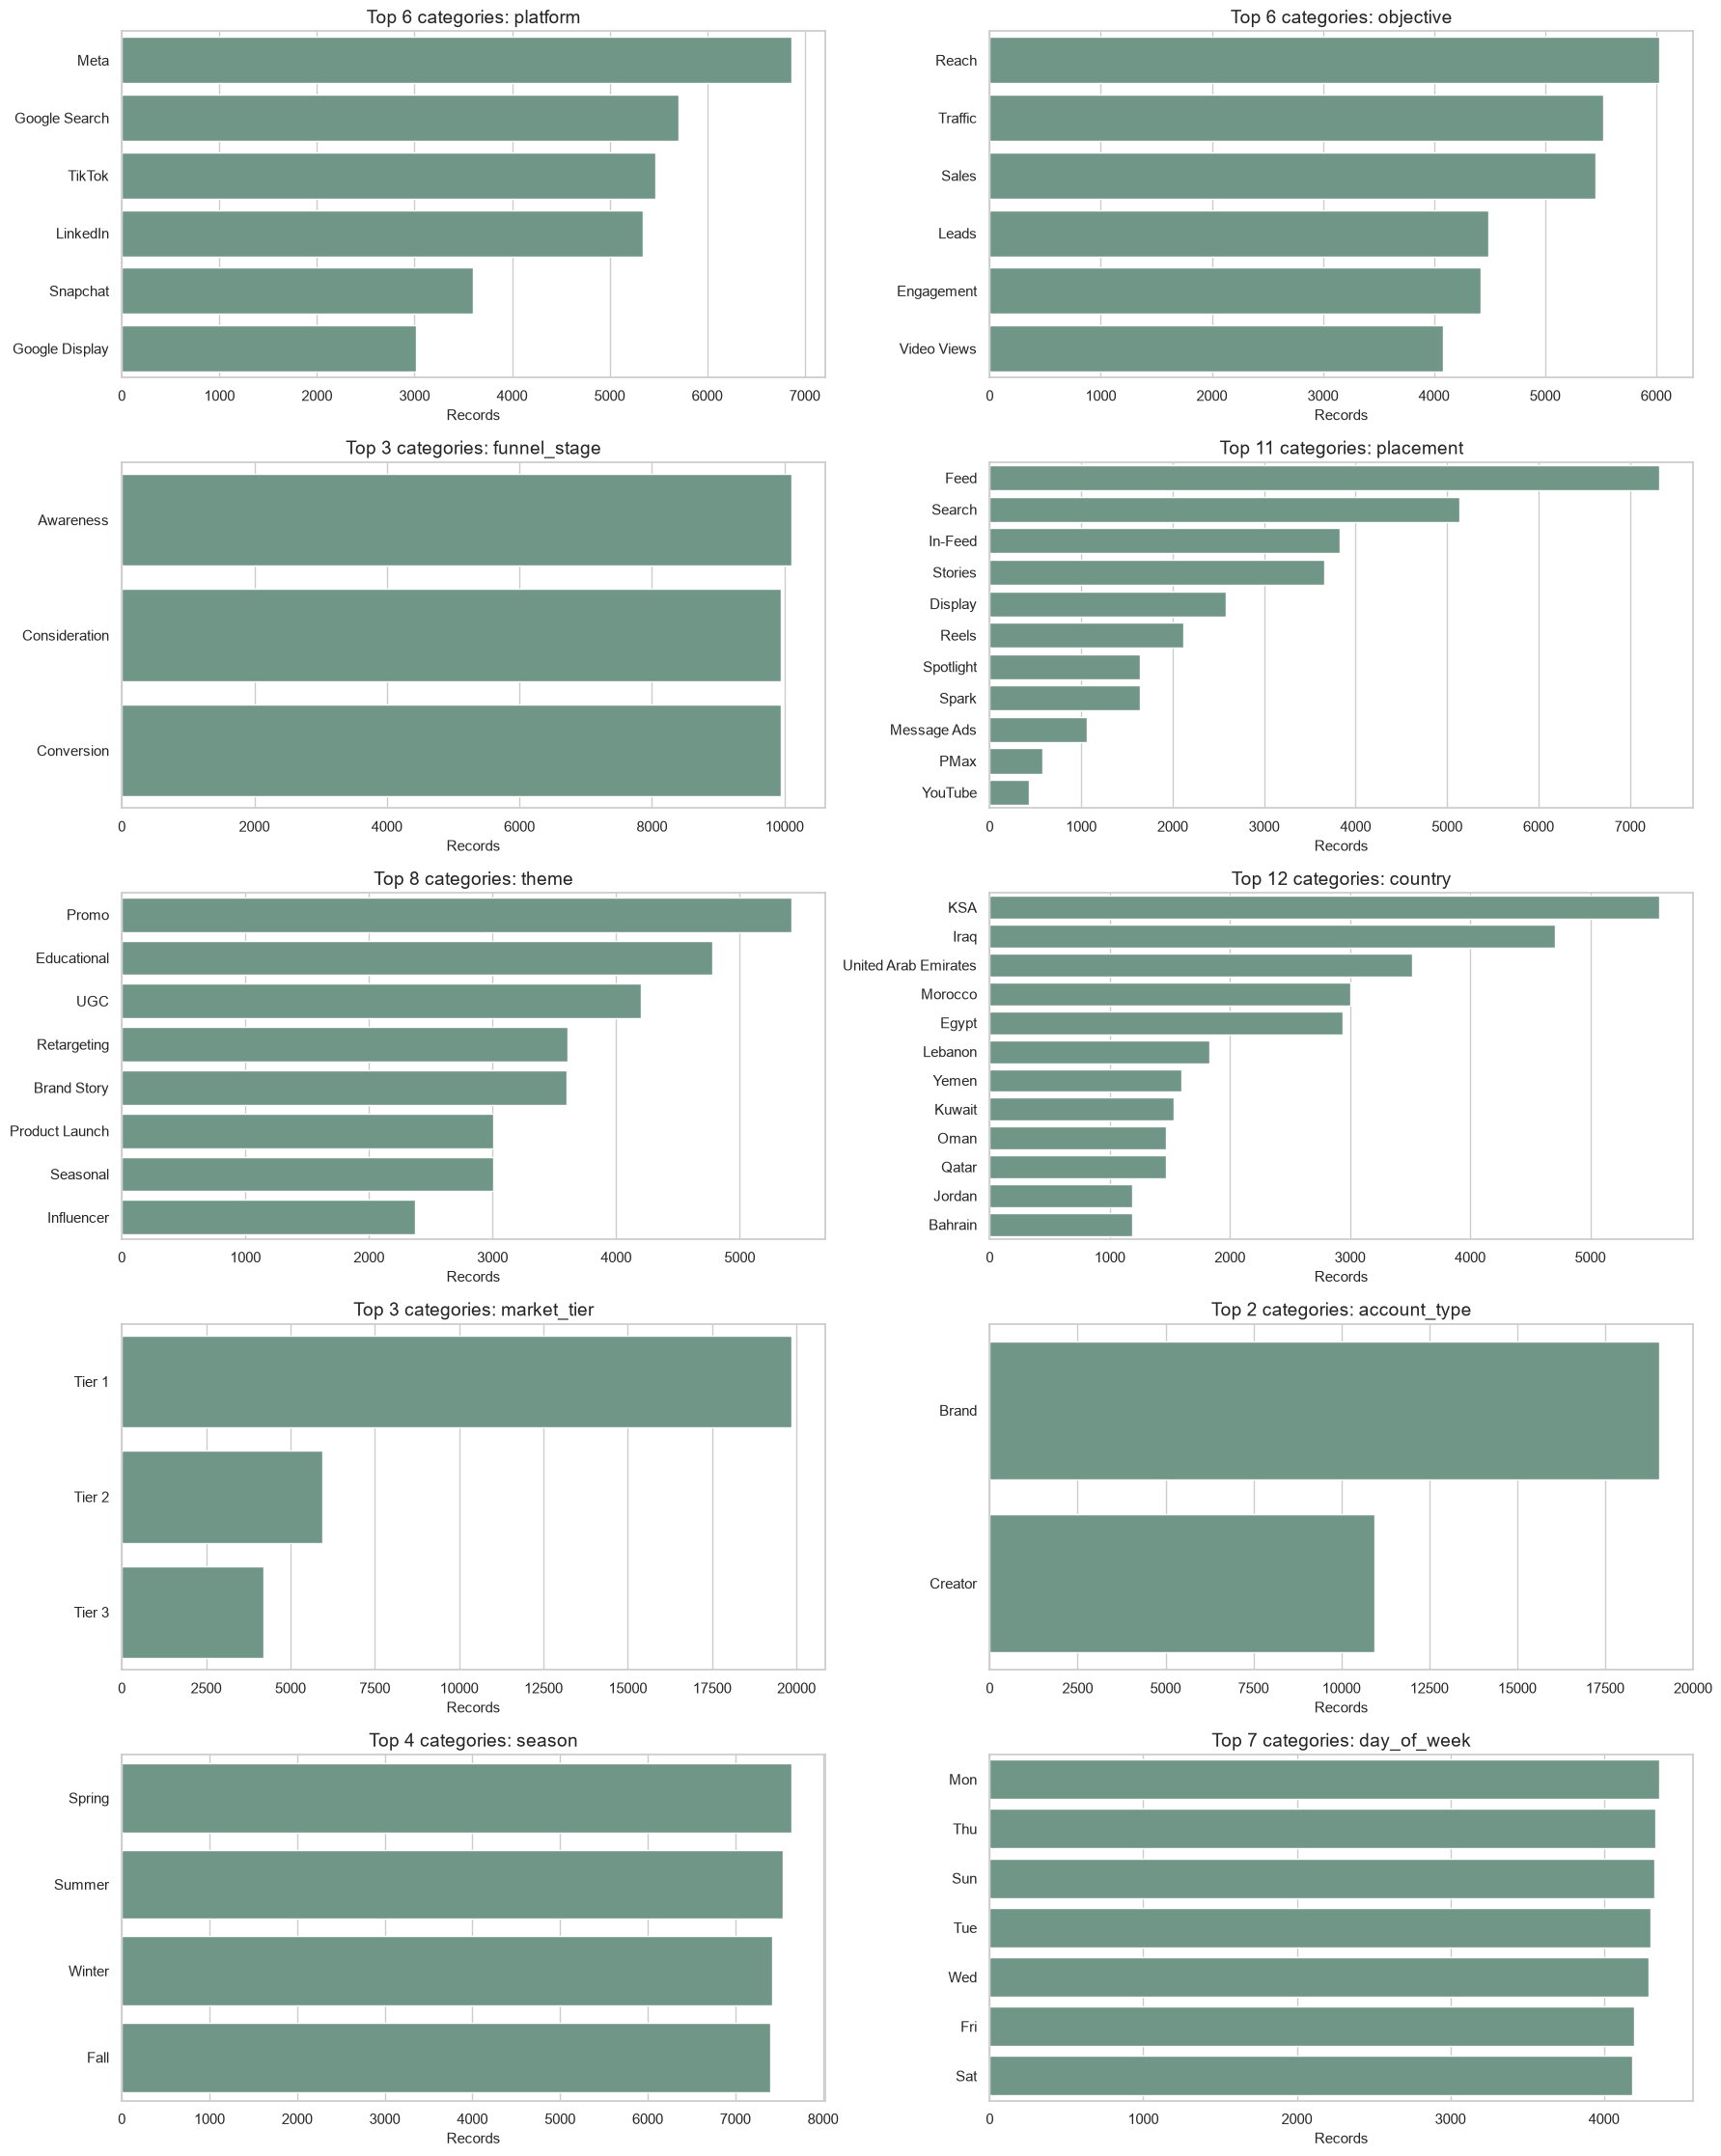

,column,unique_values,top_category,top_category_share_pct
5,country,12,KSA,18.59
3,placement,11,Feed,24.41
4,theme,8,Promo,18.07
9,day_of_week,7,Mon,14.54
1,objective,6,Reach,20.11
0,platform,6,Meta,22.89
8,season,4,Spring,25.48
2,funnel_stage,3,Awareness,33.70
6,market_tier,3,Tier 1,66.21
7,account_type,2,Brand,63.51


In [15]:
candidate_categorical = [
    "platform", "objective", "funnel_stage", "placement", "theme", "country",
    "market_tier", "account_type", "season", "day_of_week"
]
categorical_cols = [col for col in candidate_categorical if col in df_eda.columns]

n_cols = 2
n_rows = int(np.ceil(len(categorical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, categorical_cols):
    order = df_eda[col].value_counts().head(12).index
    sns.countplot(data=df_eda, y=col, order=order, ax=ax, color="#6a9c89")
    ax.set_title(f"Top {min(12, len(order))} categories: {col}")
    ax.set_xlabel("Records")
    ax.set_ylabel("")

for ax in axes[len(categorical_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

category_summary = []
for col in categorical_cols:
    category_summary.append({
        "column": col,
        "unique_values": df_eda[col].nunique(dropna=True),
        "top_category": df_eda[col].mode(dropna=True).iloc[0] if not df_eda[col].mode(dropna=True).empty else np.nan,
        "top_category_share_pct": df_eda[col].value_counts(normalize=True, dropna=True).iloc[0] * 100,
    })

display(pd.DataFrame(category_summary).sort_values("unique_values", ascending=False))


**Interpretation.** High-frequency categories can dominate aggregate revenue patterns, while sparse categories may be noisy for modeling. Platform, objective, and funnel stage are especially important because they encode marketing intent and should be evaluated against revenue directly.


## 8. Temporal Variables Analysis

Marketing performance often varies by month, weekday, holiday periods, and campaign timing. This section inspects revenue patterns over time without creating forecasting models.


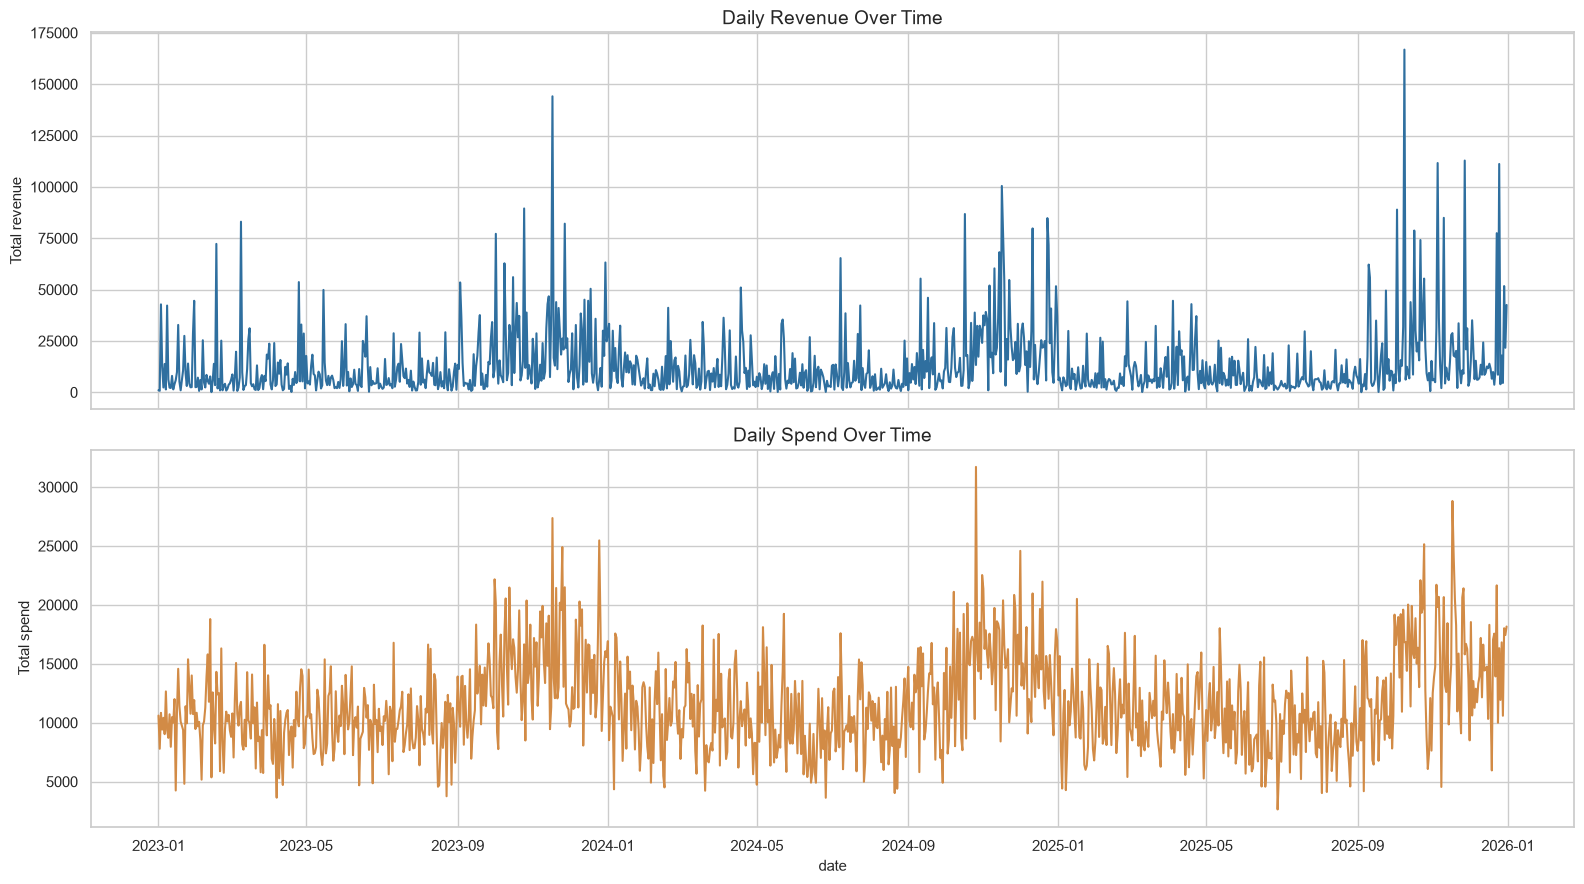

### Revenue by year

,year,records,total_revenue,avg_revenue
1,2024,10047,"5,004,513.45",498.11
0,2023,10039,"4,725,681.40",470.73
2,2025,9914,"4,541,159.41",458.06


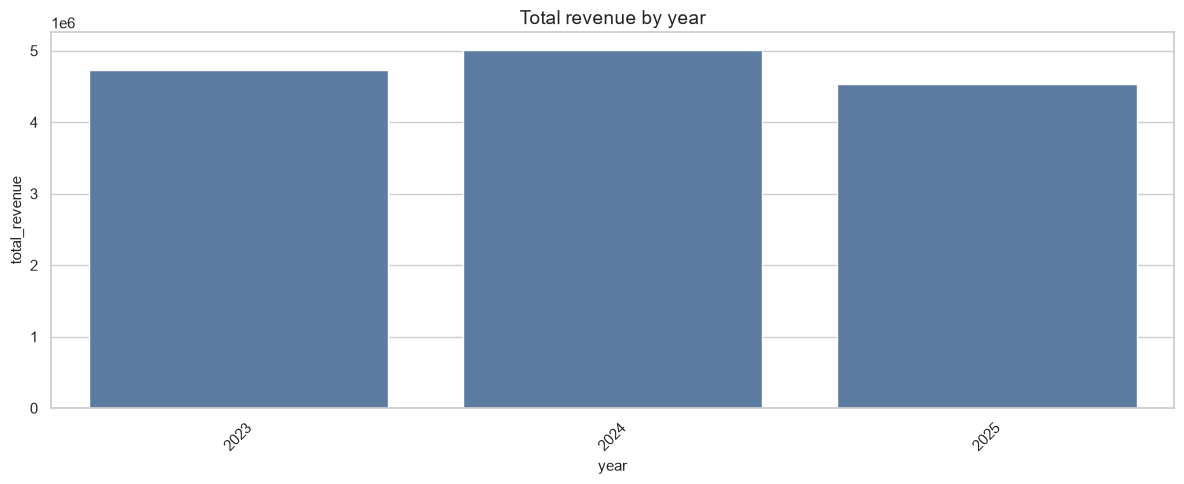

### Revenue by month_name

,month_name,records,total_revenue,avg_revenue
9,Nov,2451,"2,472,206.20","1,008.65"
10,Oct,2565,"2,184,115.70",851.51
2,Dec,2594,"1,978,988.74",762.91
11,Sep,2382,"1,152,119.25",483.68
0,Apr,2515,"1,066,912.71",424.22
4,Jan,2558,"955,428.72",373.51
7,Mar,2552,"867,914.09",340.09
8,May,2577,"814,378.65",316.02
5,Jul,2618,"794,259.93",303.38
3,Feb,2266,"725,229.42",320.05


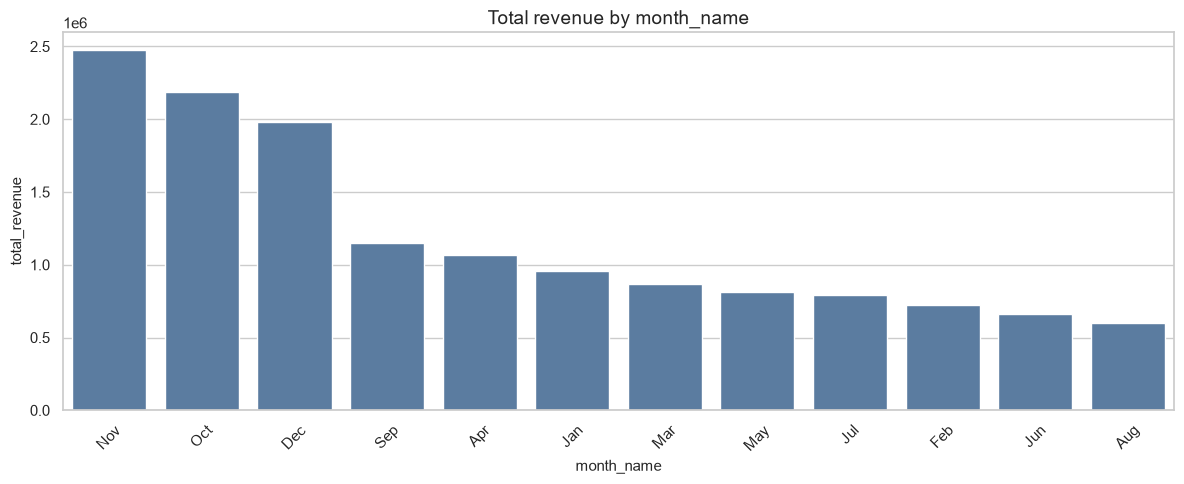

### Revenue by day_of_week

,day_of_week,records,total_revenue,avg_revenue
4,Thu,4335,"2,293,968.44",529.17
1,Mon,4363,"2,242,137.64",513.90
6,Wed,4292,"2,203,352.47",513.36
0,Fri,4195,"2,152,412.20",513.09
5,Tue,4301,"2,101,634.51",488.64
2,Sat,4186,"1,670,524.00",399.07
3,Sun,4328,"1,607,325.00",371.38


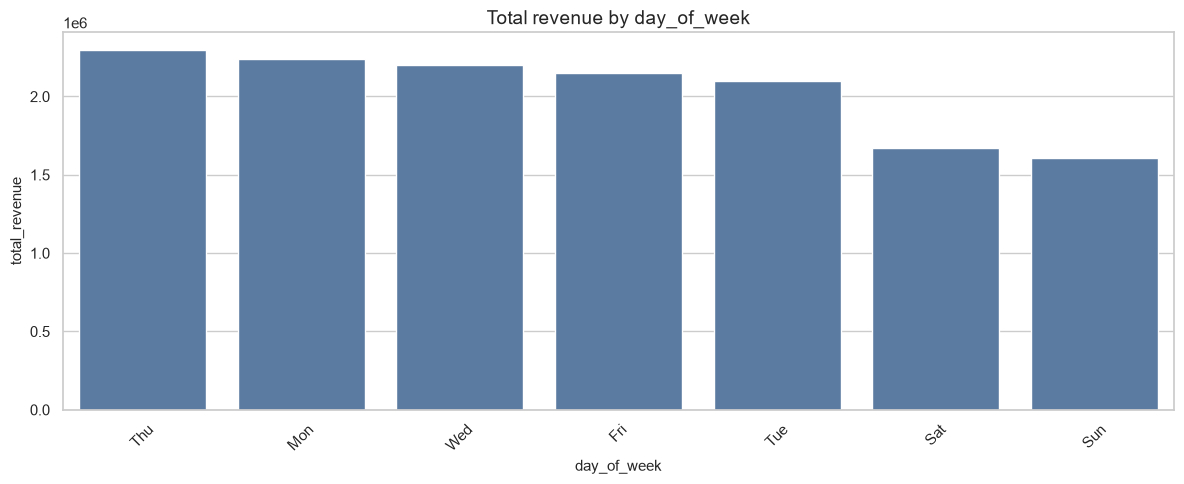

### Revenue by season

,season,records,total_revenue,avg_revenue
0,Fall,7398,"5,808,441.15",785.14
3,Winter,7418,"3,659,646.88",493.35
1,Spring,7644,"2,749,205.45",359.66
2,Summer,7540,"2,054,060.78",272.42


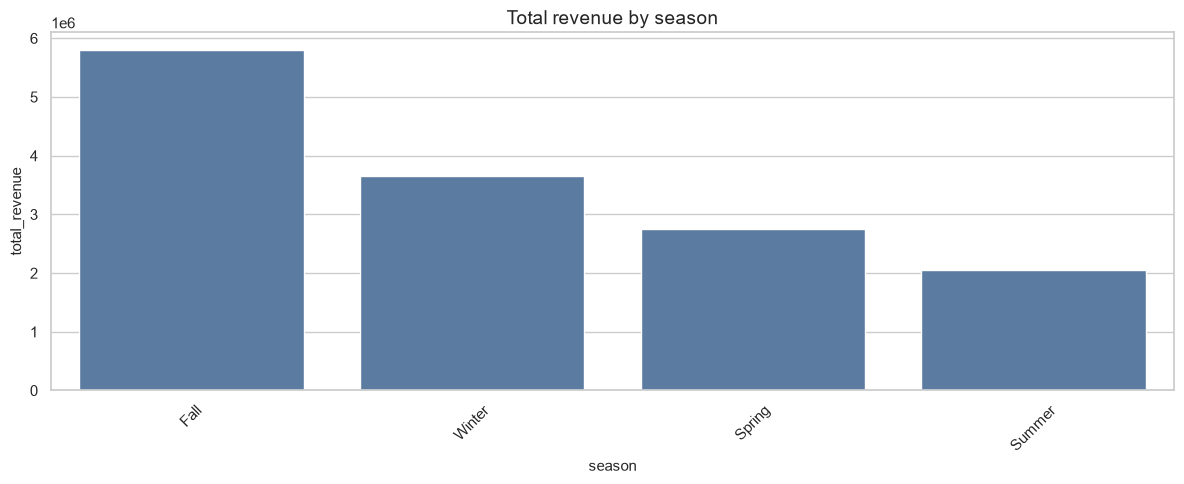

### Revenue by is_holiday

,is_holiday,records,total_revenue,avg_revenue
0,0,29525,"13,841,466.47",468.80
1,1,475,"429,887.79",905.03


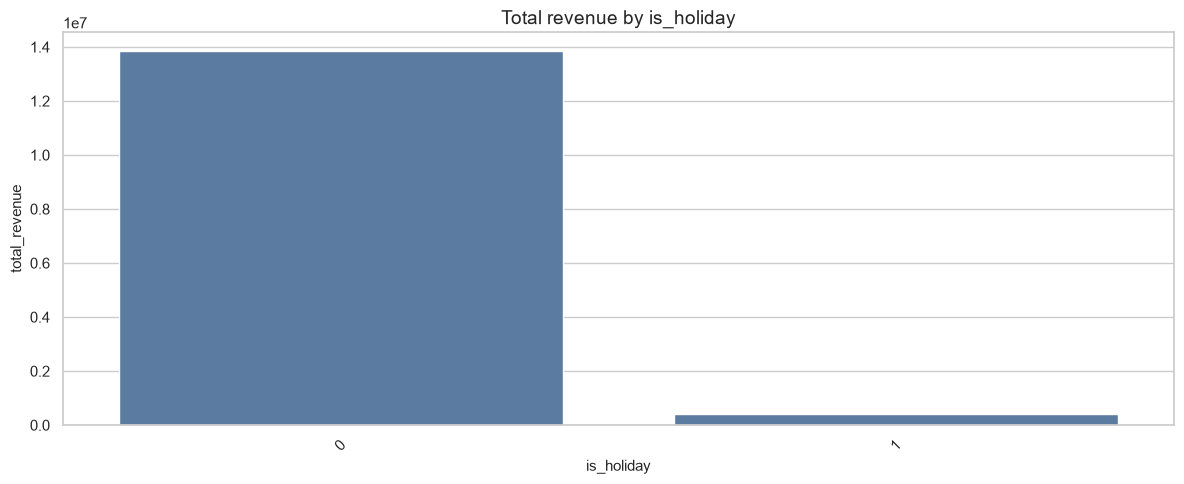

### Revenue by is_weekend

,is_weekend,records,total_revenue,avg_revenue
0,0,21486,"10,993,505.26",511.66
1,1,8514,"3,277,849.00",385.00


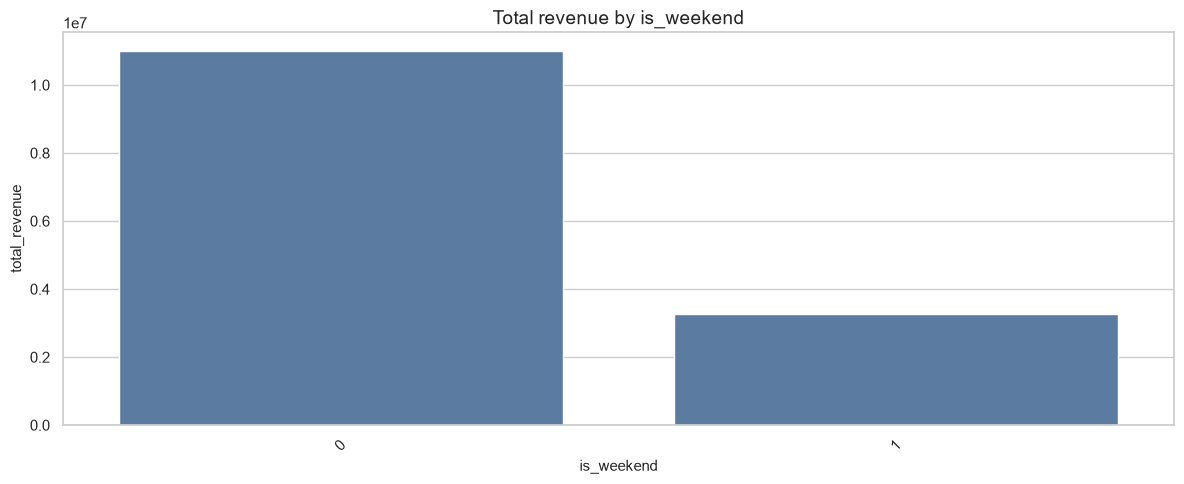

### Revenue by post_hour

,post_hour,records,total_revenue,avg_revenue
11,11,1264,"780,607.36",617.57
18,18,1269,"733,889.10",578.32
7,7,1251,"733,714.63",586.50
13,13,1260,"715,289.51",567.69
8,8,1261,"710,109.18",563.13
10,10,1240,"707,341.51",570.44
21,21,1267,"705,644.45",556.94
23,23,1237,"652,635.52",527.60
12,12,1193,"635,270.80",532.50
15,15,1293,"604,849.87",467.79


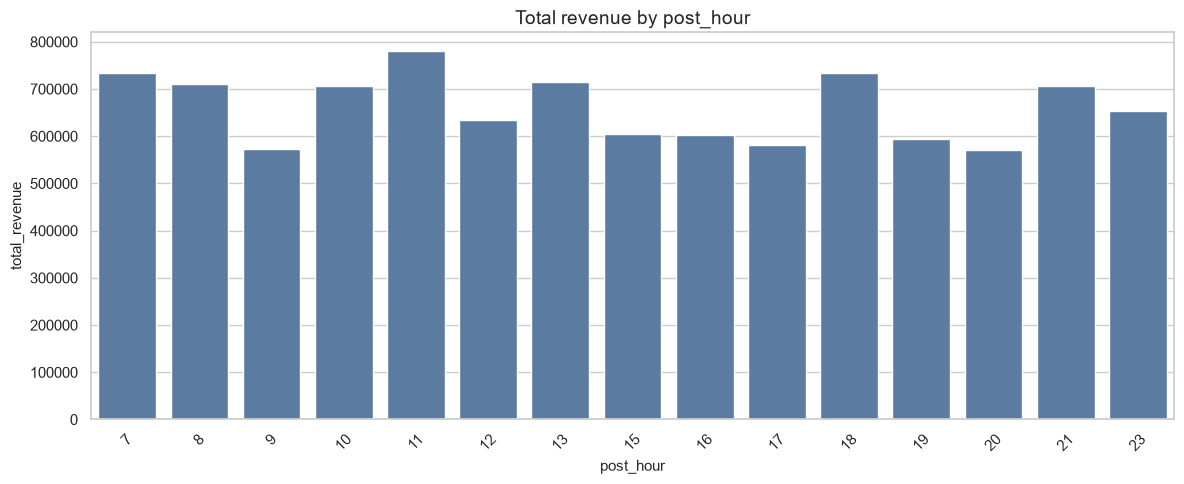

In [17]:
if "date" in df_eda.columns and df_eda["date"].notna().any():
    daily = (
        df_eda.groupby("date", as_index=False)
        .agg(revenue=(TARGET, "sum"), spend=("spend", "sum") if "spend" in df_eda.columns else (TARGET, "size"))
        .sort_values("date")
    )

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
    sns.lineplot(data=daily, x="date", y="revenue", ax=axes[0], color="#2f6f9f")
    axes[0].set_title("Daily Revenue Over Time")
    axes[0].set_ylabel("Total revenue")

    if "spend" in df_eda.columns:
        sns.lineplot(data=daily, x="date", y="spend", ax=axes[1], color="#d28b46")
        axes[1].set_title("Daily Spend Over Time")
        axes[1].set_ylabel("Total spend")
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.show()

time_group_cols = [col for col in ["year", "month_name", "day_of_week", "season", "is_holiday", "is_weekend", "post_hour"] if col in df_eda.columns]

for col in time_group_cols:
    temporal_summary = (
        df_eda.groupby(col, dropna=False)
        .agg(records=(TARGET, "size"), total_revenue=(TARGET, "sum"), avg_revenue=(TARGET, "mean"))
        .reset_index()
        .sort_values("total_revenue", ascending=False)
    )
    display(Markdown(f"### Revenue by {col}"))
    display(temporal_summary.head(15))

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=temporal_summary.head(15), x=col, y="total_revenue", ax=ax, color="#4f7cac")
    ax.set_title(f"Total revenue by {col}")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


**Interpretation.** Temporal differences can reveal seasonality, weekday effects, holiday effects, or campaign pacing patterns. These patterns may later support calendar features, but this notebook only identifies opportunities.


## 9. Bivariate Analysis vs Revenue

This section connects candidate predictors directly to `revenue`. It compares revenue against key numeric drivers and categorical marketing dimensions to identify signals for regression modeling.


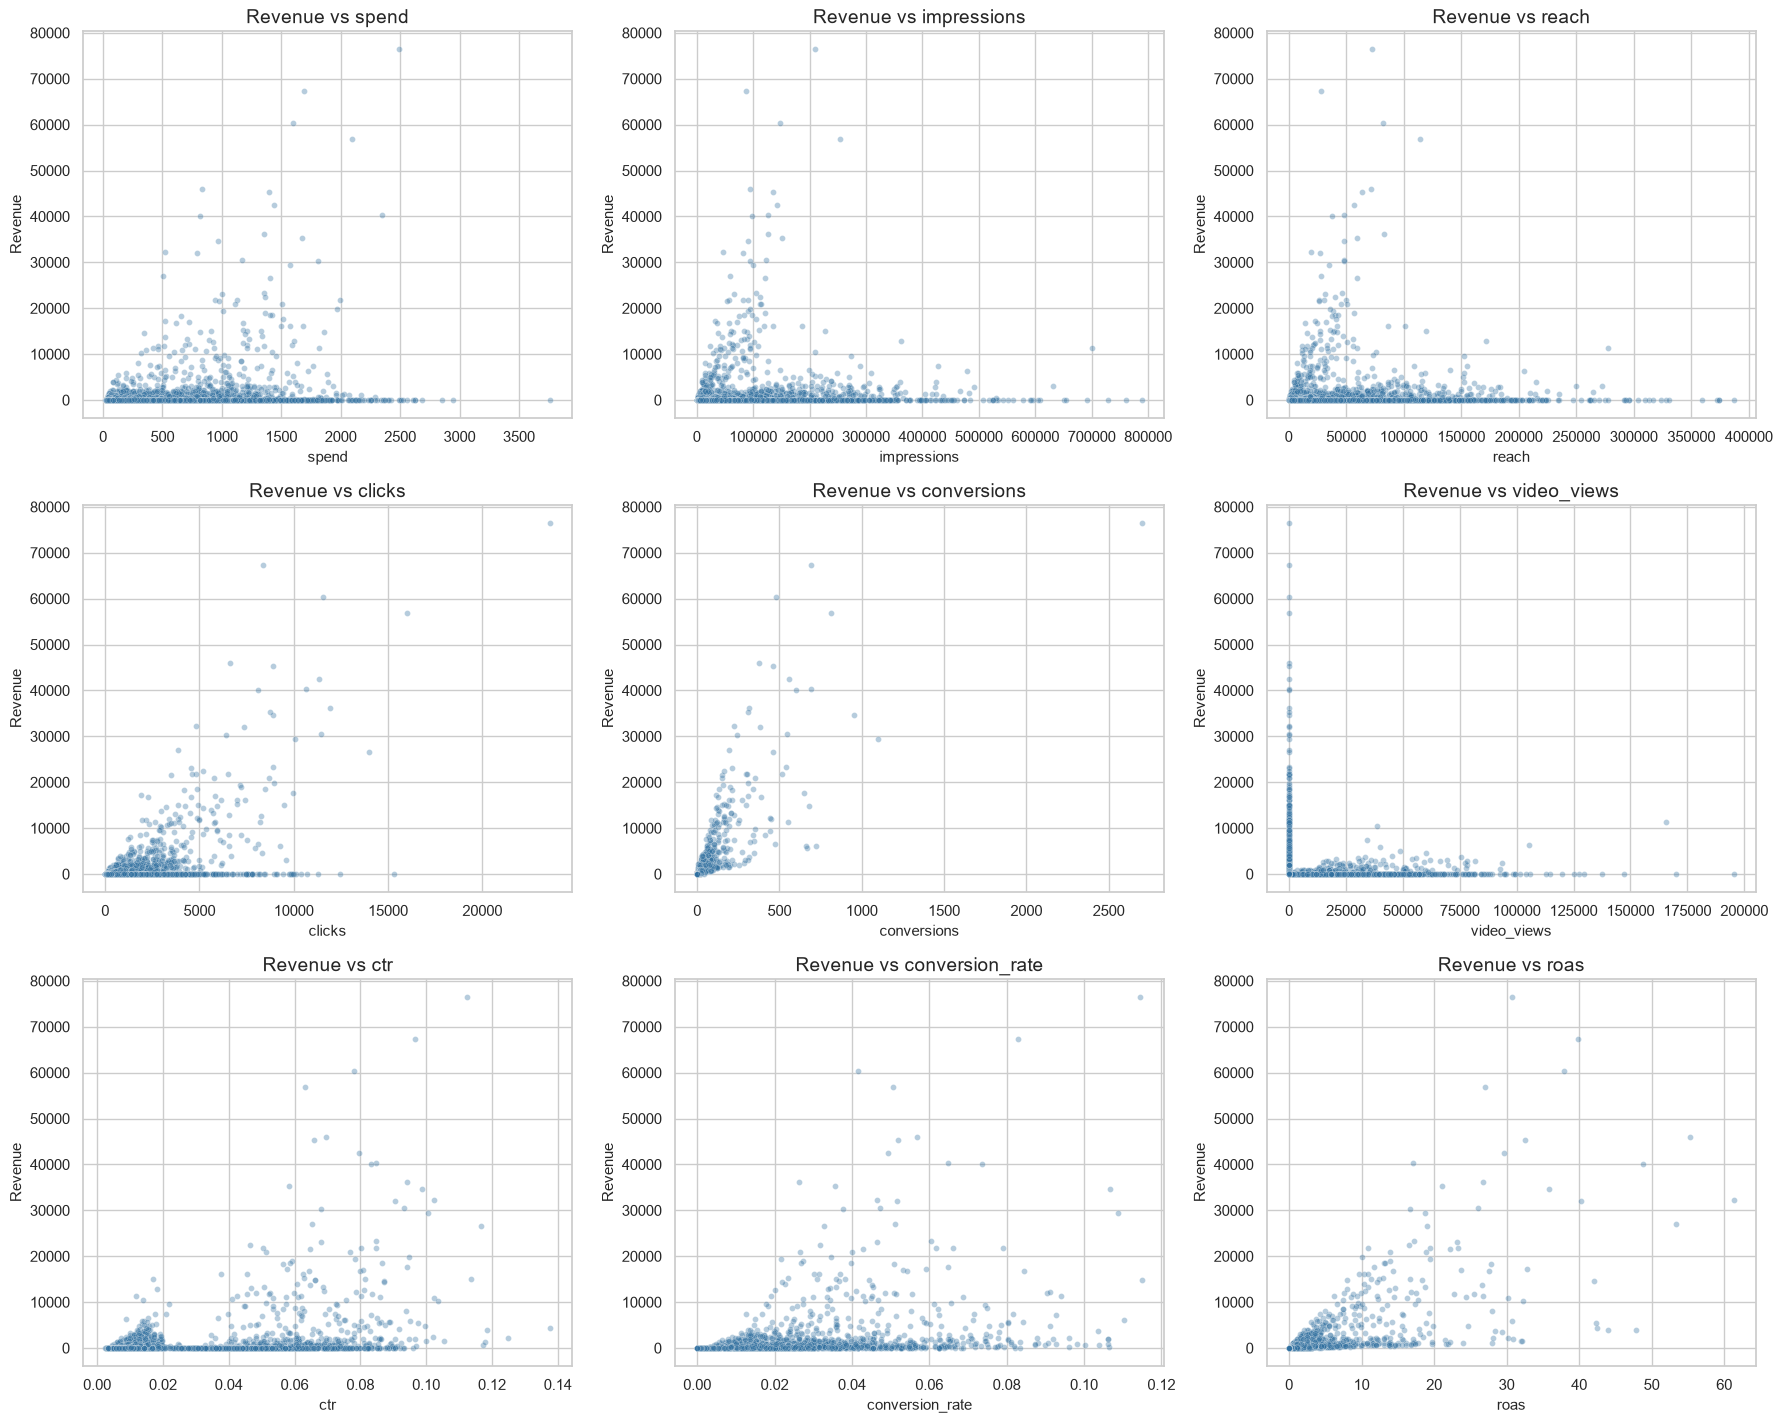

### Revenue by platform

,platform,records,total_revenue,avg_revenue,median_revenue
1,Google Search,5709,"10,362,175.17","1,815.06",0.00
3,Meta,6867,"1,640,105.78",238.84,0.00
5,TikTok,5467,"993,860.85",181.79,0.00
4,Snapchat,3603,"669,736.81",185.88,0.00
0,Google Display,3015,"328,505.21",108.96,0.00
2,LinkedIn,5339,"276,970.44",51.88,0.00


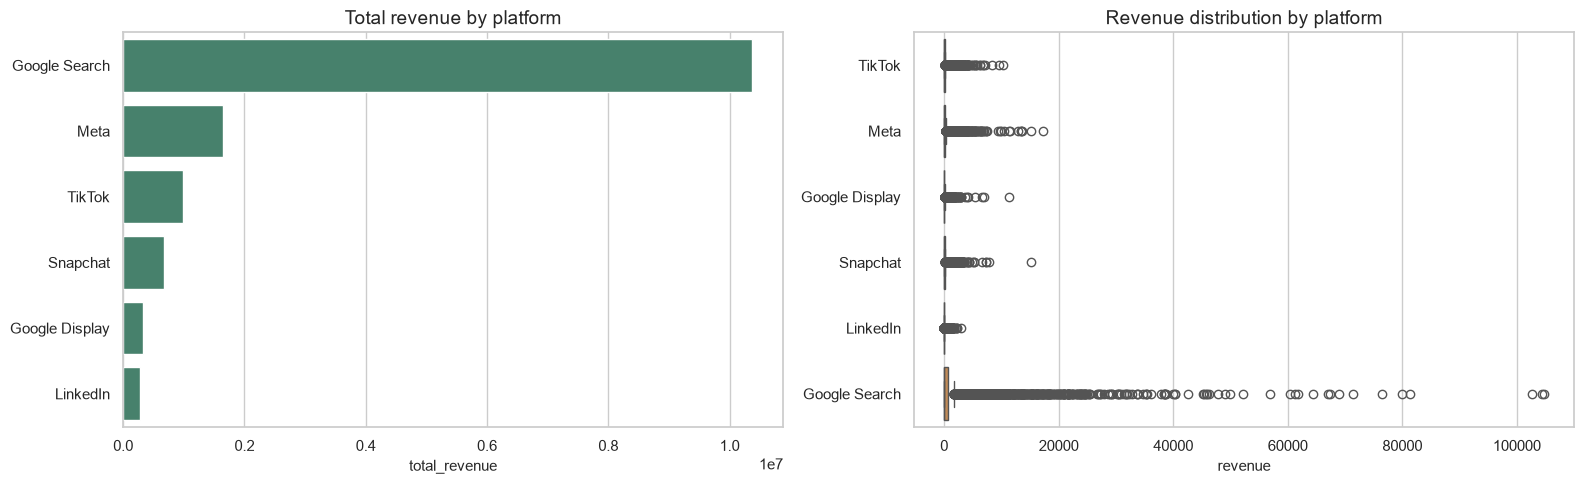

### Revenue by objective

,objective,records,total_revenue,avg_revenue,median_revenue
3,Sales,5453,"10,332,830.64","1,894.89",338.55
1,Leads,4490,"3,938,523.62",877.18,178.36
0,Engagement,4420,0.00,0.00,0.00
2,Reach,6032,0.00,0.00,0.00
4,Traffic,5527,0.00,0.00,0.00
5,Video Views,4078,0.00,0.00,0.00


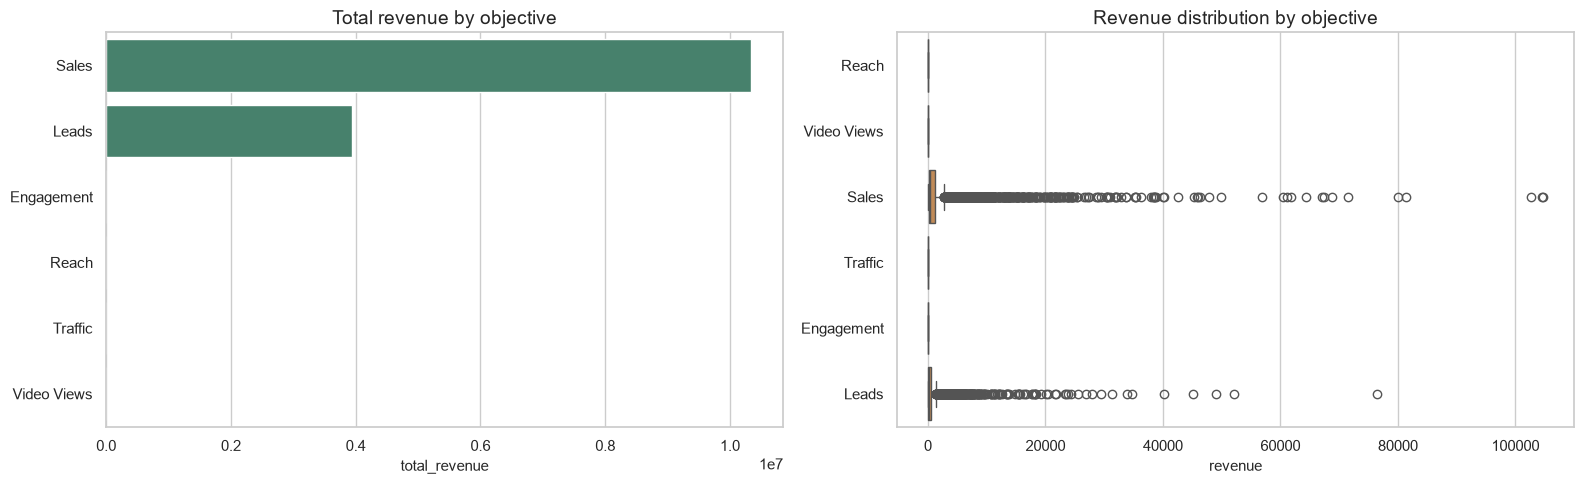

### Revenue by funnel_stage

,funnel_stage,records,total_revenue,avg_revenue,median_revenue
2,Conversion,9943,"14,271,354.26","1,435.32",257.06
0,Awareness,10110,0.00,0.00,0.00
1,Consideration,9947,0.00,0.00,0.00


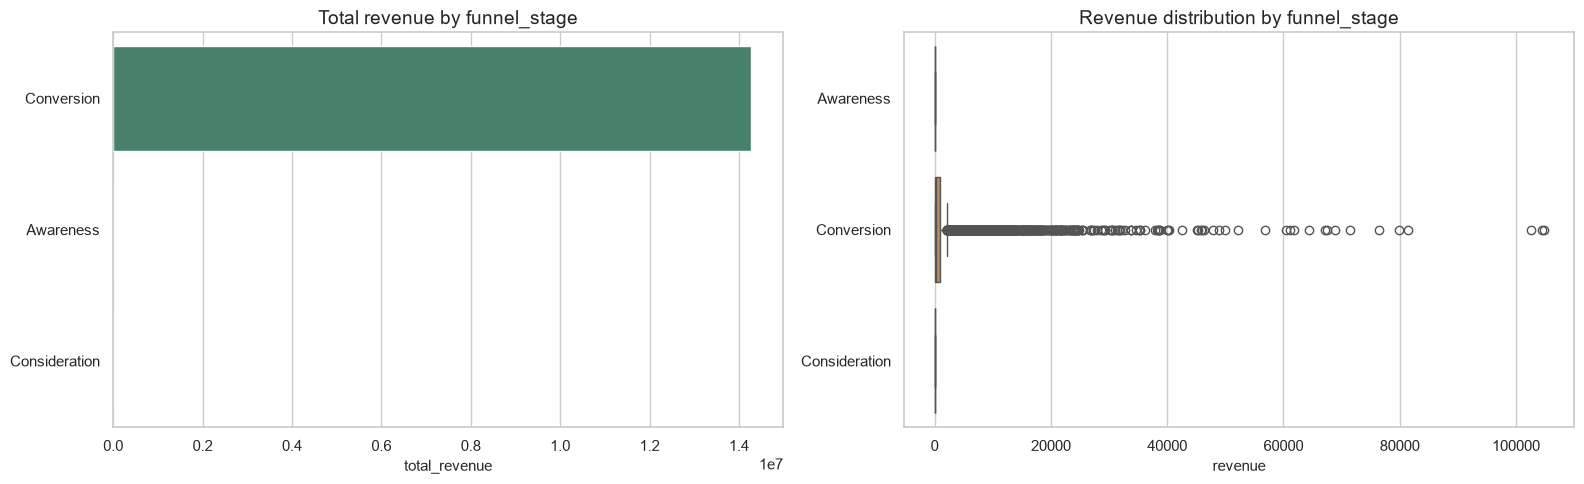

### Revenue by market_tier

,market_tier,records,total_revenue,avg_revenue,median_revenue
0,Tier 1,19862,"9,832,811.56",495.06,0.00
1,Tier 2,5936,"2,444,332.35",411.78,0.00
2,Tier 3,4202,"1,994,210.35",474.59,0.00


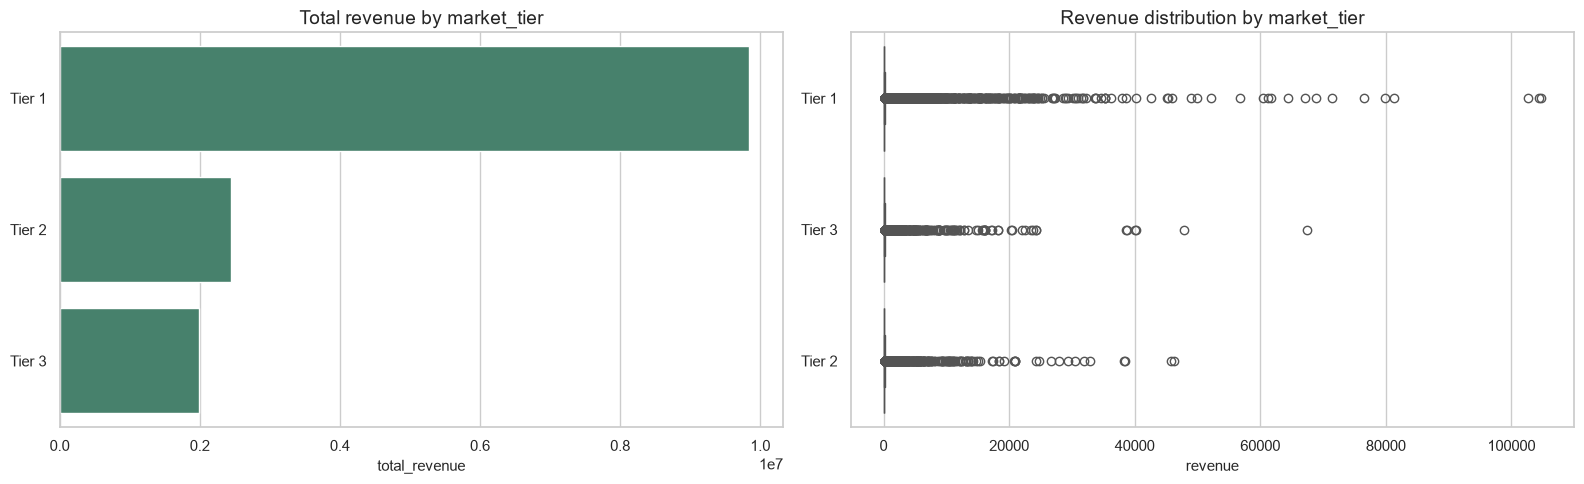

### Revenue by account_type

,account_type,records,total_revenue,avg_revenue,median_revenue
0,Brand,19053,"8,351,578.32",438.33,0.00
1,Creator,10947,"5,919,775.94",540.77,0.00


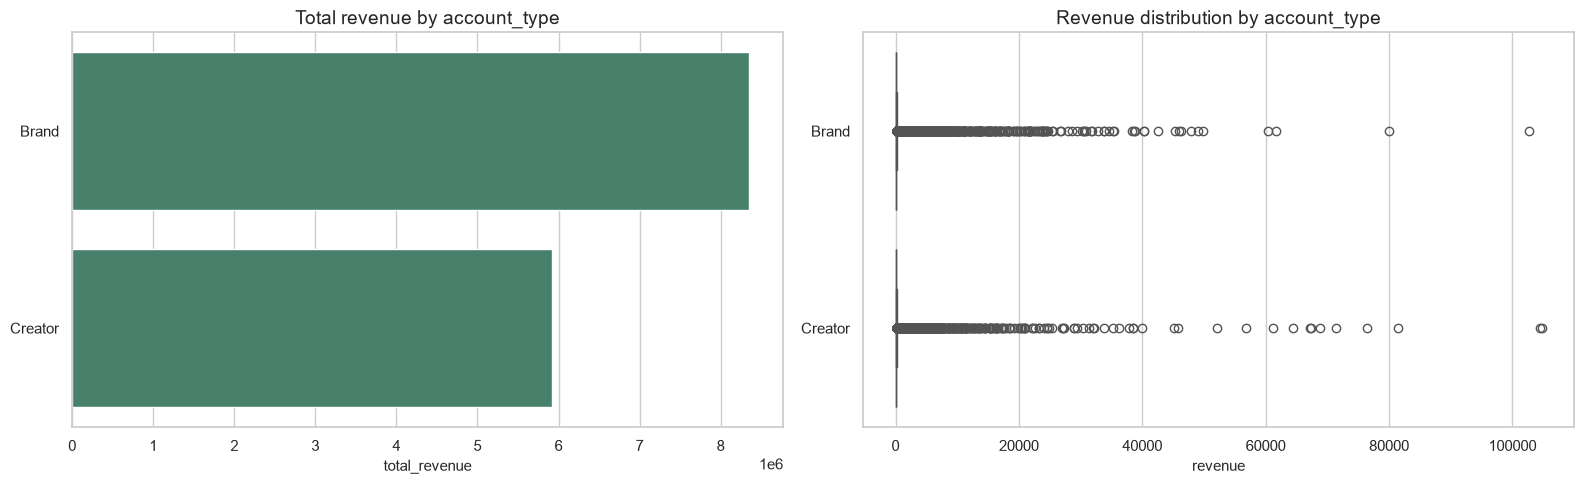

### Revenue by theme

,theme,records,total_revenue,avg_revenue,median_revenue
4,Promo,5421,"2,466,853.01",455.05,0.00
7,UGC,4204,"2,108,521.73",501.55,0.00
1,Educational,4779,"2,015,348.27",421.71,0.00
5,Retargeting,3610,"1,840,618.20",509.87,0.00
0,Brand Story,3596,"1,727,333.28",480.35,0.00
3,Product Launch,3008,"1,615,707.57",537.14,0.00
6,Seasonal,3008,"1,325,252.66",440.58,0.00
2,Influencer,2374,"1,171,719.54",493.56,0.00


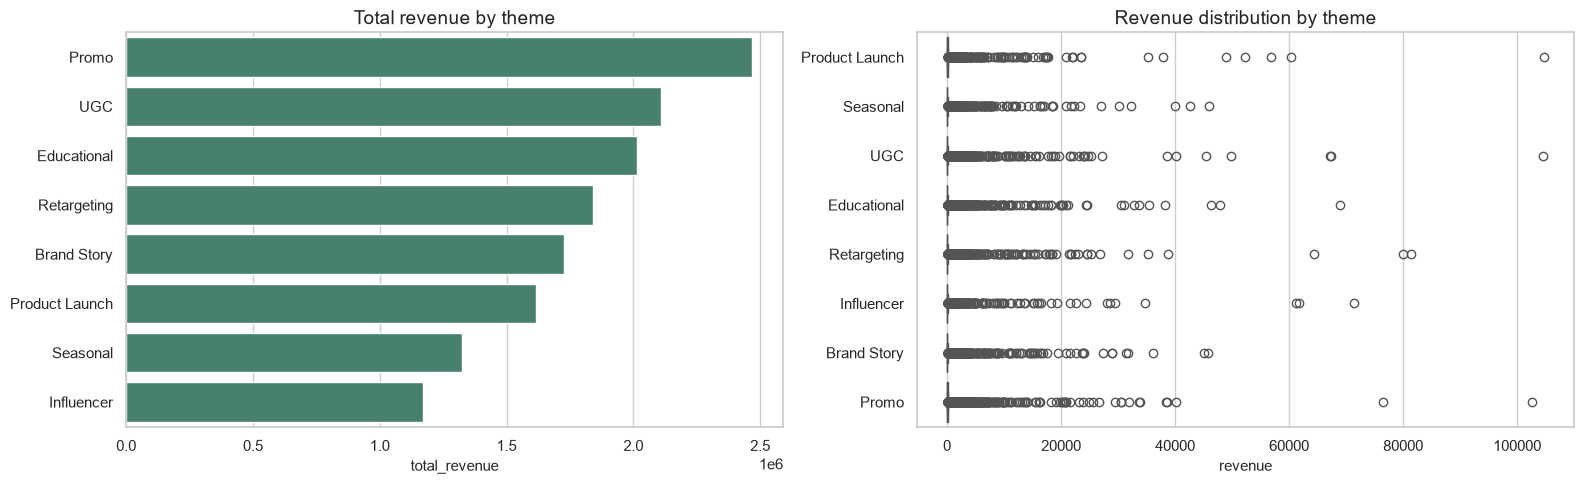

In [18]:
numeric_vs_revenue = [col for col in ["spend", "impressions", "reach", "clicks", "conversions", "video_views", "ctr", "conversion_rate", "roas"] if col in df_eda.columns]

n_cols = 3
n_rows = int(np.ceil(len(numeric_vs_revenue) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.8 * n_rows))
axes = np.array(axes).reshape(-1)

sample_df = df_eda.sample(min(len(df_eda), 6000), random_state=42)
for ax, col in zip(axes, numeric_vs_revenue):
    sns.scatterplot(data=sample_df, x=col, y=TARGET, alpha=0.35, s=18, ax=ax, color="#2f6f9f")
    ax.set_title(f"Revenue vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Revenue")

for ax in axes[len(numeric_vs_revenue):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

categorical_vs_revenue = [col for col in ["platform", "objective", "funnel_stage", "market_tier", "account_type", "theme"] if col in df_eda.columns]

for col in categorical_vs_revenue:
    summary = (
        df_eda.groupby(col, dropna=False)
        .agg(records=(TARGET, "size"), total_revenue=(TARGET, "sum"), avg_revenue=(TARGET, "mean"), median_revenue=(TARGET, "median"))
        .reset_index()
        .sort_values("total_revenue", ascending=False)
    )
    display(Markdown(f"### Revenue by {col}"))
    display(summary)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.barplot(data=summary.head(12), y=col, x="total_revenue", ax=axes[0], color="#3d8b6f")
    axes[0].set_title(f"Total revenue by {col}")
    axes[0].set_ylabel("")

    sns.boxplot(data=df_eda[df_eda[col].isin(summary[col].head(12))], y=col, x=TARGET, ax=axes[1], color="#d28b46")
    axes[1].set_title(f"Revenue distribution by {col}")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()


**Interpretation.** Strong revenue separation across objectives, funnel stages, or platforms suggests that campaign intent and channel mix are likely meaningful predictors. Numeric scatterplots help distinguish linear relationships from threshold effects or outlier-driven patterns.


## 10. Correlation Analysis

Correlation analysis highlights linear relationships among numeric variables and identifies potential multicollinearity. It is not a substitute for modeling, but it helps prioritize features and transformations.


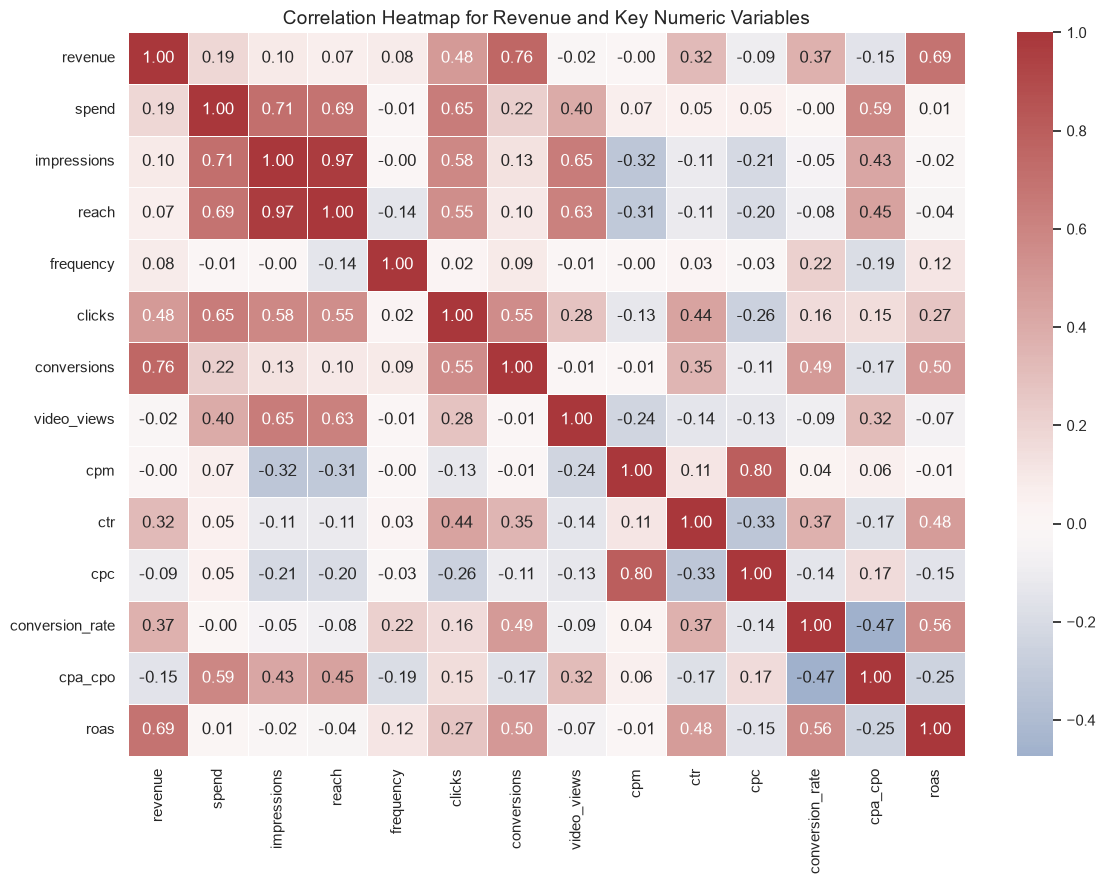

,correlation_with_revenue
conversions,0.76
roas,0.69
clicks,0.48
conversion_rate,0.37
ctr,0.32
spend,0.19
cpa_cpo,-0.15
impressions,0.10
cpc,-0.09
frequency,0.08


In [19]:
correlation_cols = [TARGET] + [col for col in key_numeric if col != TARGET and col in df_eda.columns]
correlation_data = df_eda[correlation_cols].replace([np.inf, -np.inf], np.nan)
correlation_matrix = correlation_data.corr(method="pearson")

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap for Revenue and Key Numeric Variables")
plt.tight_layout()
plt.show()

target_correlations = (
    correlation_matrix[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda series: series.abs(), ascending=False)
    .to_frame("correlation_with_revenue")
)
display(target_correlations)


**Interpretation.** Variables with high absolute correlation to revenue may be strong baseline predictors. Highly correlated predictor pairs, such as impressions and reach or clicks and conversions, should be handled carefully in linear models to avoid unstable coefficients.


## 11. Outlier Analysis

Marketing datasets commonly include unusually large campaigns, viral creative, or extreme efficiency values. This section inspects outliers without removing them.


,column,lower_bound,upper_bound,outlier_count,outlier_pct,p99,max
5,revenue,-108.52,180.88,5730,19.10,"10,043.73","104,733.41"
6,roas,-0.73,1.22,5001,16.67,19.20,92.00
4,conversions,-4.50,7.50,4947,16.49,202.01,"2,701.00"
3,clicks,"-1,169.00","2,239.00",2982,9.94,"7,316.07","30,884.00"
2,reach,"-40,211.50","79,426.50",2751,9.17,"203,756.19","682,100.00"
1,impressions,"-80,839.88","159,887.12",2691,8.97,"388,359.50","1,015,972.00"
7,cpa_cpo,-440.02,793.03,1367,8.74,"1,694.11","3,759.94"
0,spend,-698.60,"1,394.06",1497,4.99,"2,005.98","3,759.94"


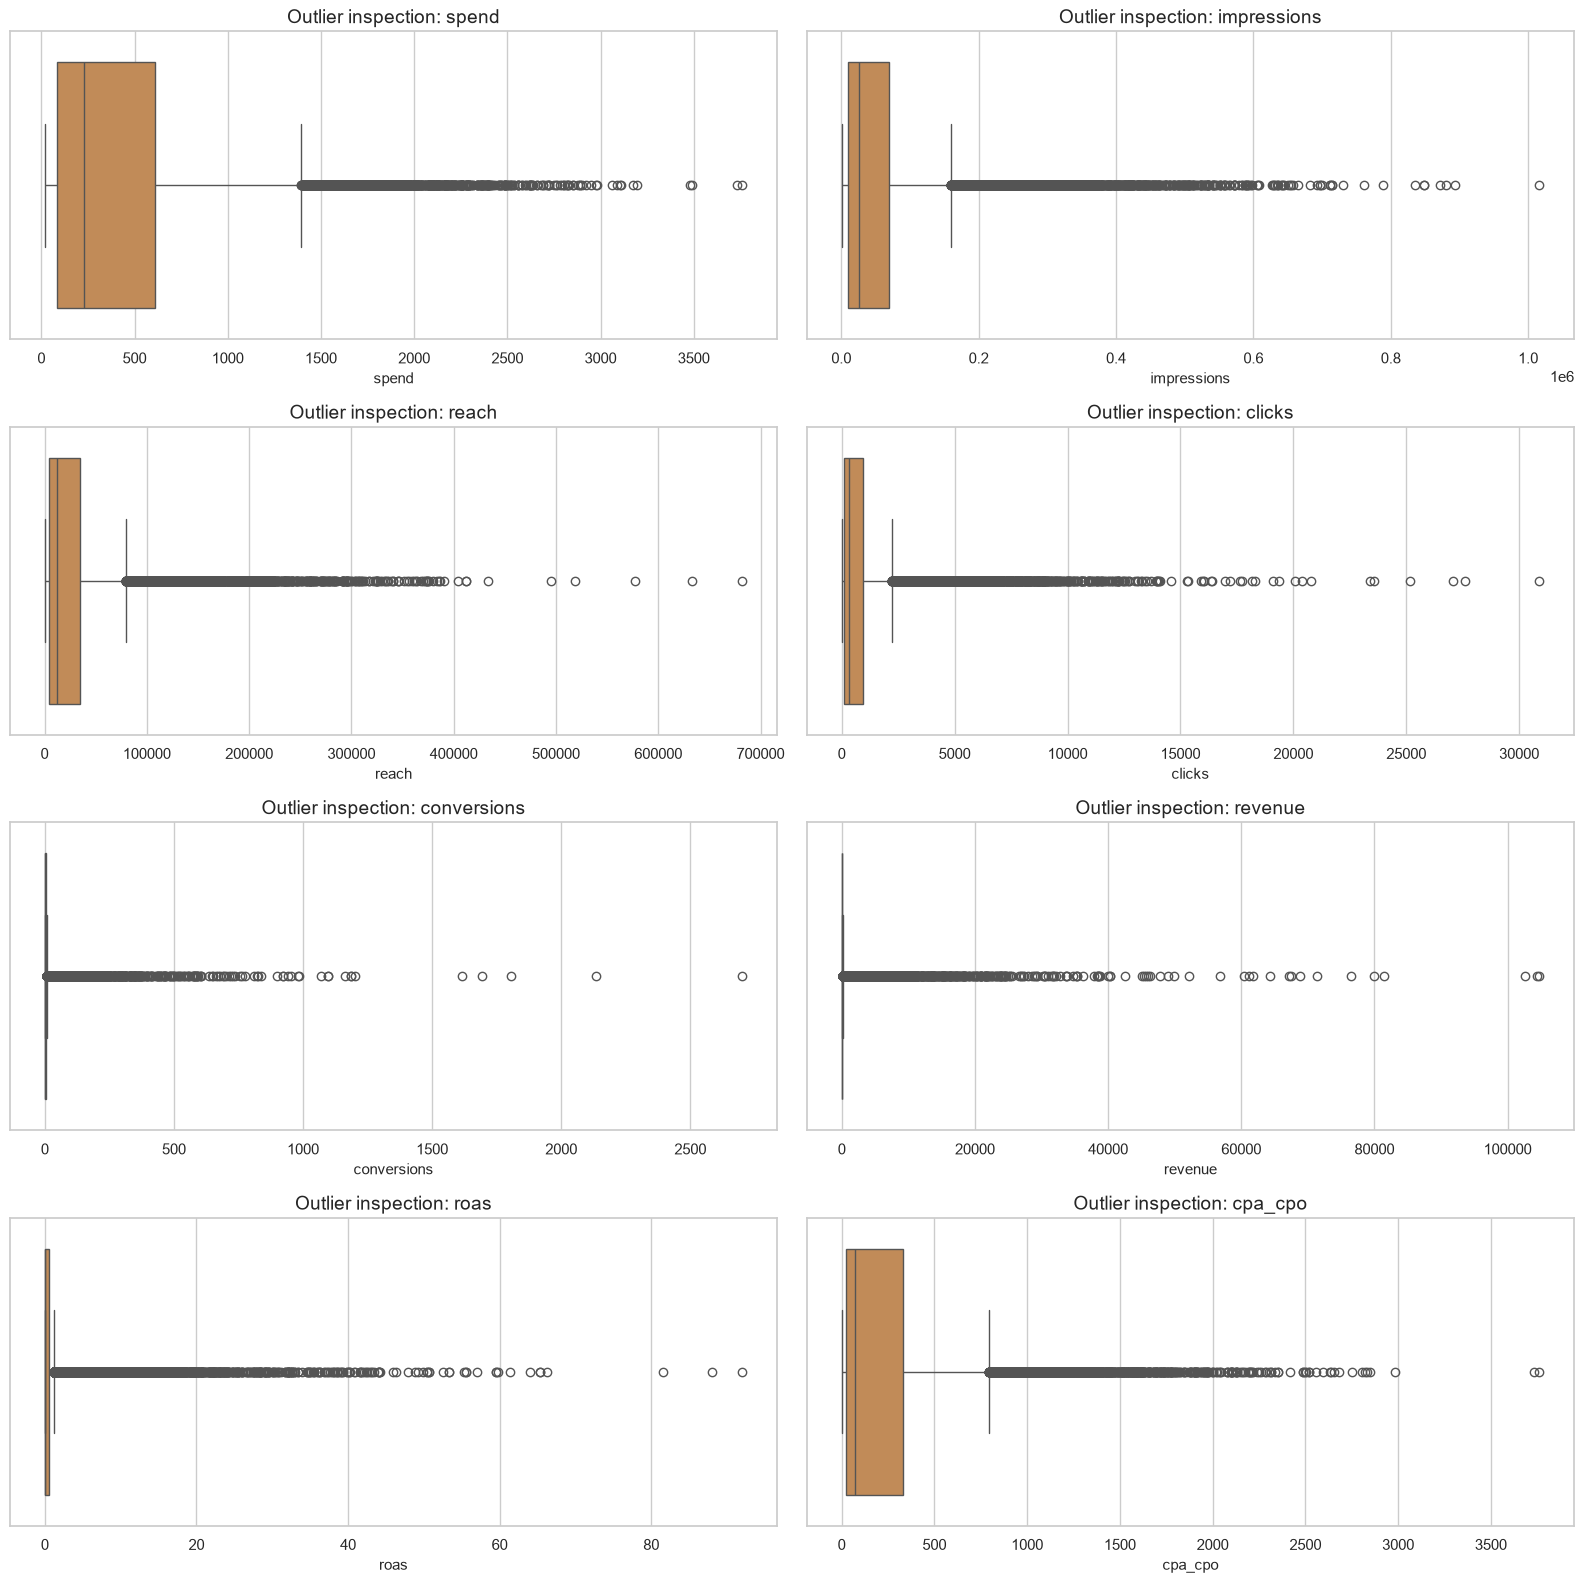

,date,platform,objective,funnel_stage,country,spend,clicks,conversions,revenue,roas
22463,2025-12-25,Google Search,Sales,Conversion,United Arab Emirates,"2,510.28",27605,1186,"104,733.41",41.72
28178,2023-11-17,Google Search,Sales,Conversion,KSA,"1,755.19",17654,1071,"104,461.03",59.52
17324,2025-10-09,Google Search,Sales,Conversion,Iraq,"2,824.62",16968,736,"102,600.75",36.32
23559,2025-11-05,Google Search,Sales,Conversion,Iraq,884.46,11516,714,"81,371.34",92.00
8070,2023-03-09,Google Search,Sales,Conversion,Morocco,"1,522.30",11660,591,"79,940.36",52.51
9267,2023-10-25,Google Search,Leads,Conversion,KSA,"2,488.84",23583,2701,"76,467.23",30.72
6935,2023-11-27,Google Search,Sales,Conversion,KSA,"1,286.37",12628,502,"71,438.60",55.54
19984,2024-11-17,Google Search,Sales,Conversion,Oman,"1,359.09",10577,486,"68,852.20",50.66
2444,2024-10-17,Google Search,Sales,Conversion,Lebanon,"1,693.81",8374,694,"67,419.23",39.80
692,2025-10-17,Google Search,Sales,Conversion,Iraq,"1,345.45",12144,923,"67,103.49",49.87


In [20]:
outlier_cols = [col for col in ["spend", "impressions", "reach", "clicks", "conversions", TARGET, "roas", "cpa_cpo"] if col in df_eda.columns]

def iqr_outlier_summary(data, columns):
    rows = []
    for col in columns:
        series = data[col].replace([np.inf, -np.inf], np.nan).dropna()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        rows.append({
            "column": col,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": ((series < lower) | (series > upper)).sum(),
            "outlier_pct": ((series < lower) | (series > upper)).mean() * 100,
            "p99": series.quantile(0.99),
            "max": series.max(),
        })
    return pd.DataFrame(rows).sort_values("outlier_pct", ascending=False)

display(iqr_outlier_summary(df_eda, outlier_cols))

n_cols = 2
n_rows = int(np.ceil(len(outlier_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, outlier_cols):
    sns.boxplot(x=df_eda[col].replace([np.inf, -np.inf], np.nan), ax=ax, color="#d28b46")
    ax.set_title(f"Outlier inspection: {col}")

for ax in axes[len(outlier_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

top_revenue_cols = [col for col in ["date", "platform", "objective", "funnel_stage", "country", "spend", "clicks", "conversions", TARGET, "roas"] if col in df_eda.columns]
display(df_eda.sort_values(TARGET, ascending=False)[top_revenue_cols].head(15))


**Interpretation.** Outliers should be investigated as high-impact business events before any treatment is considered. In marketing, high-revenue rows may be valid success cases rather than data errors, especially when supported by spend, conversions, or ROAS.


## 12. Feature Engineering Opportunities

The EDA suggests candidate features that may help the modeling notebook explain revenue variation. These are opportunities only; implementation should be evaluated in the modeling workflow.


In [21]:
feature_ideas = [
    {
        "opportunity": "Log-transform revenue and scale metrics",
        "reason": "Revenue, spend, impressions, clicks, and conversions are likely right-skewed.",
        "modeling_value": "Can stabilize variance and improve fit for models sensitive to skew.",
    },
    {
        "opportunity": "Use funnel and objective indicators",
        "reason": "Revenue is structurally tied to campaign intent, especially Sales and Leads objectives.",
        "modeling_value": "Helps separate zero-revenue awareness activity from conversion-oriented activity.",
    },
    {
        "opportunity": "Create efficiency metrics",
        "reason": "CTR, conversion rate, CPA/CPO, CPM, and ROAS summarize performance intensity.",
        "modeling_value": "May capture quality differences beyond raw campaign scale.",
    },
    {
        "opportunity": "Add calendar features",
        "reason": "Month, weekday, season, holiday, and weekend patterns can affect demand and campaign performance.",
        "modeling_value": "Supports seasonality-aware revenue predictions.",
    },
    {
        "opportunity": "Model platform and placement effects",
        "reason": "Revenue can differ by channel mix and inventory surface.",
        "modeling_value": "Allows the model to learn channel-specific baseline performance.",
    },
    {
        "opportunity": "Consider interaction features",
        "reason": "Platform-by-objective or funnel-stage-by-spend effects may be stronger than individual terms.",
        "modeling_value": "Can capture nonlinear business logic in simpler models.",
    },
]

display(pd.DataFrame(feature_ideas))


,opportunity,reason,modeling_value
0,Log-transform revenue and scale metrics,"Revenue, spend, impressions, clicks, and conve...",Can stabilize variance and improve fit for mod...
1,Use funnel and objective indicators,Revenue is structurally tied to campaign inten...,Helps separate zero-revenue awareness activity...
2,Create efficiency metrics,"CTR, conversion rate, CPA/CPO, CPM, and ROAS s...",May capture quality differences beyond raw cam...
3,Add calendar features,"Month, weekday, season, holiday, and weekend p...",Supports seasonality-aware revenue predictions.
4,Model platform and placement effects,Revenue can differ by channel mix and inventor...,Allows the model to learn channel-specific bas...
5,Consider interaction features,Platform-by-objective or funnel-stage-by-spend...,Can capture nonlinear business logic in simple...


**Interpretation.** The most promising feature engineering ideas connect business logic to observed data patterns: campaign intent, scale, efficiency, channel mix, and seasonality. The modeling notebook should test these ideas empirically.


## 13. Business Insights

This section summarizes the EDA through a digital marketing lens, focusing on revenue growth, media efficiency, and campaign portfolio management.


In [22]:
business_tables = {}

for col in ["platform", "objective", "funnel_stage", "market_tier", "season"]:
    if col in df_eda.columns:
        agg_dict = {
            "records": (TARGET, "size"),
            "total_revenue": (TARGET, "sum"),
            "avg_revenue": (TARGET, "mean"),
        }
        if "spend" in df_eda.columns:
            agg_dict["total_spend"] = ("spend", "sum")
        if "conversions" in df_eda.columns:
            agg_dict["total_conversions"] = ("conversions", "sum")

        table = df_eda.groupby(col, dropna=False).agg(**agg_dict).reset_index()
        if {"total_revenue", "total_spend"}.issubset(table.columns):
            table["aggregate_roas"] = np.where(table["total_spend"] > 0, table["total_revenue"] / table["total_spend"], np.nan)
        business_tables[col] = table.sort_values("total_revenue", ascending=False)

for col, table in business_tables.items():
    display(Markdown(f"### Business view: {col}"))
    display(table)

insight_notes = [
    "Revenue concentration by objective and funnel stage indicates whether the account portfolio is primarily demand-generating or conversion-harvesting.",
    "Platform-level revenue and ROAS comparisons can guide budget allocation, but should be interpreted with campaign objective and spend mix in mind.",
    "Seasonal and weekday differences can inform flighting, promotional calendars, and pacing rules.",
    "High-revenue outliers deserve separate business review because they may represent scalable wins, unusual campaign bursts, or synthetic benchmark artifacts.",
    "Zero-revenue rows are analytically important: they represent upper-funnel activity and should not automatically be treated as bad records.",
]

display(Markdown("**Digital marketing insight summary**\n\n" + "\n".join(f"- {note}" for note in insight_notes)))


### Business view: platform

,platform,records,total_revenue,avg_revenue,total_spend,total_conversions,aggregate_roas
1,Google Search,5709,"10,362,175.17","1,815.06","2,744,251.20",216694,3.78
3,Meta,6867,"1,640,105.78",238.84,"2,636,602.54",41978,0.62
5,TikTok,5467,"993,860.85",181.79,"2,091,251.63",28281,0.48
4,Snapchat,3603,"669,736.81",185.88,"1,450,865.95",21148,0.46
0,Google Display,3015,"328,505.21",108.96,"1,157,077.08",9109,0.28
2,LinkedIn,5339,"276,970.44",51.88,"2,556,360.66",5588,0.11


### Business view: objective

,objective,records,total_revenue,avg_revenue,total_spend,total_conversions,aggregate_roas
3,Sales,5453,"10,332,830.64","1,894.89","2,081,156.04",126984,4.96
1,Leads,4490,"3,938,523.62",877.18,"1,685,817.88",181910,2.34
0,Engagement,4420,0.00,0.00,"1,579,698.12",4531,0.00
2,Reach,6032,0.00,0.00,"3,184,179.92",2258,0.00
4,Traffic,5527,0.00,0.00,"1,974,367.51",5555,0.00
5,Video Views,4078,0.00,0.00,"2,131,189.59",1560,0.00


### Business view: funnel_stage

...

### Business view: market_tier

,market_tier,records,total_revenue,avg_revenue,total_spend,total_conversions,aggregate_roas
0,Tier 1,19862,"9,832,811.56",495.06,"8,407,544.73",218190,1.17
1,Tier 2,5936,"2,444,332.35",411.78,"2,457,352.98",57610,0.99
2,Tier 3,4202,"1,994,210.35",474.59,"1,771,511.35",46998,1.13


### Business view: season

,season,records,total_revenue,avg_revenue,total_spend,total_conversions,aggregate_roas
0,Fall,7398,"5,808,441.15",785.14,"3,885,319.40",136518,1.49
3,Winter,7418,"3,659,646.88",493.35,"3,256,628.50",84119,1.12
1,Spring,7644,"2,749,205.45",359.66,"2,855,105.84",57970,0.96
2,Summer,7540,"2,054,060.78",272.42,"2,639,355.32",44191,0.78


**Digital marketing insight summary**

- Revenue concentration by objective and funnel stage indicates whether the account portfolio is primarily demand-generating or conversion-harvesting.
- Platform-level revenue and ROAS comparisons can guide budget allocation, but should be interpreted with campaign objective and spend mix in mind.
- Seasonal and weekday differences can inform flighting, promotional calendars, and pacing rules.
- High-revenue outliers deserve separate business review because they may represent scalable wins, unusual campaign bursts, or synthetic benchmark artifacts.
- Zero-revenue rows are analytically important: they represent upper-funnel activity and should not automatically be treated as bad records.

**Interpretation.** Business conclusions should balance growth and efficiency. A platform or objective with high total revenue may simply have more spend, while a smaller segment with strong ROAS may be a candidate for careful scaling.


## 14. EDA Conclusions

This EDA prepares the modeling notebook by clarifying the structure of the revenue prediction problem.

Key conclusions:

- `revenue` should remain the target variable for the regression workflow.
- Revenue distribution, zero-revenue prevalence, and outliers should influence metric selection and target transformation decisions.
- Campaign scale variables such as spend, impressions, clicks, and conversions are central predictors, but efficiency metrics add important context.
- Categorical dimensions such as platform, objective, funnel stage, placement, and market tier encode business strategy and should be evaluated as model features.
- Temporal variables may capture seasonality, holiday effects, and weekly performance patterns.
- Outliers should be reviewed as business events before any capping or transformation is applied.

The next modeling notebook should use these findings to design preprocessing, compare regression approaches, and evaluate performance with metrics that reflect the skewed and business-oriented nature of marketing revenue.

Overall, this EDA establishes a strong analytical foundation for the modeling phase. The findings obtained will guide feature selection, preprocessing strategies, model comparison, and performance evaluation while ensuring that the final solution remains aligned with the project's business objective: forecasting campaign revenue before launch
